# Exploração de Dados — Incidentes Locaweb

**Objetivo do notebook.** Mapear o comportamento da base de incidentes e identificar quais
variáveis têm poder preditivo para o alvo do projeto: **o número de incidentes P2, P3 e P4
abertos em D+1 e em D+7**.

Este notebook é *exploratório e de preparação*,
ele entrega:

1. Um diagnóstico do que a série alvo é (e do que ela **não** é);
2. Um conjunto de tabelas *silver* em grão diário, prontas para a etapa de modelagem;
3. Uma lista explícita de riscos e decisões em aberto que a modelagem precisa herdar.

---

## Como este notebook está organizado

| Seção | O que contém |
|---|---|
| **1. Configuração** | Ambiente, imports, constantes de negócio, funções utilitárias |
| **2. Transformações** | Carga, enriquecimento e construção das tabelas fato (grão dia e dia × prioridade) |
| **3. Investigações** | Quebras estruturais, sazonalidade e análise das colunas candidatas |
| **4. Salvamento** | Escrita das tabelas silver com contrato de colunas documentado |

## Sumário executivo

Os achados abaixo saíram das análises da Seção 3 e estão aqui no topo porque **condicionam toda
a modelagem**. Quem for treinar o modelo precisa ler esta seção antes de qualquer coisa.

### 1. A base não é uma série de três anos. É uma série de quatro meses.

O recorte vai de 2023-01-02 a 2025-12-31 (1.095 dias), mas o volume não está distribuído:

| Regime | Período | Dias | Incidentes | % do total | Média/dia |
|---|---|---|---|---|---|
| **R1** | até 2024-12-31 | 730 | 732 | 0,6 % | 1,0 |
| **R2** | 2025-01-01 a 2025-09-02 | 243 | 28.388 | 23,2 % | 116,8 |
| **R3** | a partir de 2025-09-03 | 122 | 93.423 | 76,2 % | 765,8 |

**R1 é um artefato de extração, não um regime de negócio.** A Locaweb entregou os incidentes
*abertos ou encerrados em 2025*; o que aparece em 2023/2024 são apenas os poucos casos de vida
longa que atravessaram o ano. R1 deve ser descartado da modelagem, não tratado como "época de
poucos incidentes".

Na prática, o histórico utilizável tem **365 dias**, e o regime mais recente tem **122**.

### 2. O salto de setembro/2025 é uma mudança de instrumentação, não de operação.

De R2 para R3 o volume diário multiplica por ~6,5. Três evidências apontam para a mesma causa:

| Métrica | R2 | R3 |
|---|---|---|
| Status `Sem Intervenção` | 82 incidentes (0,3 %) | 80.288 (85,9 %) |
| Aberto por `Monitoramento` | 54,9 % | 94,8 % |
| Duração **mediana** | 1,55 h | **0,16 h** (≈ 10 min) |

Ou seja: entrou em produção um pipeline de monitoramento que abre e fecha o alerta
automaticamente, quase sempre em minutos. O crescimento é maior justamente onde não há gente
trabalhando — fim de semana/feriado cresce 10,4× contra 5,7× em dia útil, e madrugada cresce
9,9× contra 4,6× à tarde. Uma operação humana não cresce assim.

> **Implicação direta para o alvo.** "Quantos incidentes P2/P3/P4 teremos em D+1" significa coisas
> diferentes antes e depois de setembro. É preciso decidir com a área de negócio se o alvo inclui
> os tickets `Sem Intervenção`. A Seção 3.2 constrói as duas séries lado a lado para essa decisão.

### 3. A mistura de prioridades também mudou.

| Prioridade | % em R2 | % em R3 |
|---|---|---|
| P2 | 19,9 % | 10,7 % |
| P3 | 58,7 % | 26,3 % |
| P4 | 20,4 % | 62,9 % |

P3 deixa de ser a prioridade dominante e P4 assume. Isso é consistente com o item 2: alerta
automático de baixa severidade. **Modelar as três prioridades com um único modelo compartilhado
é arriscado** — elas não responderam à quebra do mesmo jeito.

### 4. O volume é concentrado em poucos itens de configuração.

Em R3, **16 % dos ICs ativos concentram 89 % dos incidentes**. A base tem 9.171 ICs, mas a mediana
é de 2 incidentes por IC no período inteiro. Features de IC devem ser construídas sobre a cauda
pesada (contagem de ICs outlier ativos no dia), não sobre médias da base toda.

### 5. Um único time responde por três quartos da base.

Team14 tem 92.775 dos 122.543 incidentes (75,7 %). A coluna `Grupo designado` tem 17 valores
distintos, não 14 — a Seção 3.5 reconcilia essa diferença.

---

## Riscos e decisões em aberto

| # | Questão | Onde é tratada |
|---|---|---|
| 1 | O alvo inclui tickets `Sem Intervenção`? | §3.2 |
| 2 | D+7 é a contagem *no* dia D+7 ou o acumulado D+1..D+7? | §2.10 (gera as duas) |
| 3 | Com 122 dias de regime atual, cabe validação temporal honesta? | §3.9 |
| 4 | As faixas de OLA são por prioridade ou sobre o volume total? | §2.8 |
| 5 | 17 grupos designados vs. 14 times informados | §3.5 |

## Dicionário de dados (tabela bronze)

122.543 registros, 23 colunas.

**Chave**
- `Número` — identificador do incidente (`INC…`).

**Categóricas**

| Coluna | Distintos | % nulo | Observação |
|---|---|---|---|
| `Prioridade` | 5 | 0 % | `1 - Crítica` … `5 - Muito Baixa`. P1 e P5 são residuais (1 e 333 registros) |
| `Aberto por` | 2 | 0 % | `Manual` / `Monitoramento` |
| `Status` | 4 | 0 % | `Encerrado`, `Encerrado Automaticamente`, `Sem Intervenção`, `Aguardando Problema` |
| `Grupo designado` | 17 | 0 % | Time responsável |
| `Descrição Resumida` | 17.787 | 0 % | Texto livre, majoritariamente gerado por alerta |
| `Item de configuração` | 9.171 | 1,5 % | Ativo afetado |
| `Categoria` | 141 | 63,4 % | |
| `Subcategoria` | 447 | 63,4 % | |
| `Produto` | 51 | 63,6 % | |
| `Solução` | 2 | 87,5 % | |
| `Incidente Pai` | 3.326 | 87,7 % | Vínculo com incidente-pai |

> Atenção ao bloco `Categoria` / `Subcategoria` / `Produto`: os três têm ~63 % de nulo e nulidade
> praticamente idêntica (77.719 / 77.720 / 77.935). Não é ausência aleatória — é um subconjunto de
> incidentes que simplesmente não passa por classificação. §3.6 investiga qual.

**Temporais** — `Aberto`, `Resolvido` (67 % nulo), `Encerrado`. Todas em UTC.

**Numéricas** — `Duração` (segundos), `Tempo_Pos_Resolução`, `Diferença_Limite_Duração`.

**Validação** (vindas do tratamento bronze) — `Duração_is_inconsistent`, `Modified_Record`,
`Resolvido_after_Encerrado`, `Entrou para KPI?`, `KPI Violado?`.

## Convenções adotadas

**Nomenclatura.** `snake_case` em tudo que este notebook cria. Colunas originais mantêm o nome
de origem até o ponto de renomeação explícita, em `renomear_colunas_bronze()`.

Prefixos: `inc_` contagem de incidentes · `taxa_` percentual (0–100) · `ac_` acumulado ·
`ic_` item de configuração · `y_` variável alvo.

**Grão das tabelas.**

| Tabela | Grão | Para quê |
|---|---|---|
| `df` | incidente | Base enriquecida |
| `fato_diario` | dia | Métricas que não se dividem por prioridade (calendário, IC, times) |
| `fato_diario_prioridade` | dia × prioridade | Núcleo: alvo e features por prioridade |
| `fato_diario_prioridade_turno` | dia × prioridade × turno | Sazonalidade intradiária |
| `dim_*` | entidade | Perfis de IC, time e template de descrição |

**Vazamento temporal.** Toda feature em D usa apenas informação disponível **até o fim de D**.
Alvos são criados com `shift(-h)`. Janelas móveis incluem o dia corrente — o que é legítimo,
porque o alvo está em D+1 ou D+7. Isso é reafirmado em §2.10.

---
# 1. Configuração

## 1.1 Ambiente e caminhos

In [143]:
import sys
import os

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    from google.colab import drive, userdata

    drive.mount("/content/drive")
    RAIZ = "/content/drive/MyDrive/fiap/segundo ano/challenge_locaweb/"
    BASE_PATH = RAIZ + "1_bronze_data/"
    SAVE_PATH = RAIZ + "2_silver_data/"
    os.environ["ANTHROPIC_API_KEY"] = userdata.get("minha-chave-api-claude")
else:
    # arquivo .env
    from .env import load_dotenv
    os.environ["ANTHROPIC_API_KEY"] = load_dotenv("ANTHROPIC_API_KEY")
    BASE_PATH = "../1_bronze_data/"
    SAVE_PATH = "../2_silver_data/"
    os.environ["ANTHROPIC_API_KEY"] =

print(f"Ambiente : {'Google Colab' if IN_COLAB else 'Local'}")
print(f"Python   : {sys.version.split()[0]}")
print(f"Leitura  : {BASE_PATH}")
print(f"Escrita  : {SAVE_PATH}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Ambiente : Google Colab
Python   : 3.13.15
Leitura  : /content/drive/MyDrive/fiap/segundo ano/challenge_locaweb/1_bronze_data/
Escrita  : /content/drive/MyDrive/fiap/segundo ano/challenge_locaweb/2_silver_data/


In [79]:
# ruptures não vem no Colab por padrão.
try:
    import ruptures  # noqa: F401
except ImportError:
    %pip install -q ruptures

In [104]:
# ruptures não vem no Colab por padrão.
try:
    import anthropic  # noqa: F401
except ImportError:
    %pip install anthropic

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 20.7 MB/s eta 0:00:00


## 1.2 Imports

In [80]:
import re
import unicodedata
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import ruptures as rpt
import seaborn as sns
from pandas.tseries.holiday import AbstractHolidayCalendar, Day, Easter, Holiday
from scipy import stats

warnings.filterwarnings("ignore", category=FutureWarning)

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")

### Padrão visual

Há um
único tema, aplicado uma vez. Todo gráfico usa `novo_grafico()`, que já devolve a figura no
tamanho e com a grade certos — assim nenhuma célula precisa repetir `figsize`, `title`, `grid`.

In [81]:
PALETA = {
    "p2": "#C0392B",   # vermelho  — alta
    "p3": "#E67E22",   # laranja   — média
    "p4": "#F1C40F",   # amarelo   — baixa
    "total": "#2C3E50",
    "neutro": "#95A5A6",
    "destaque": "#2980B9",
    "r1": "#BDC3C7",
    "r2": "#7F8C8D",
    "r3": "#34495E",
}
COR_PRIORIDADE = {2: PALETA["p2"], 3: PALETA["p3"], 4: PALETA["p4"]}

sns.set_theme(
    style="whitegrid",
    rc={
        "figure.figsize": (12, 4.5),
        "figure.dpi": 110,
        "axes.titlesize": 13,
        "axes.titleweight": "bold",
        "axes.titlelocation": "left",
        "axes.labelsize": 10,
        "axes.edgecolor": "#DDDDDD",
        "grid.color": "#EEEEEE",
        "grid.linewidth": 0.8,
        "legend.frameon": False,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
    },
)


def novo_grafico(titulo, subtitulo=None, figsize=(12, 4.5), ncols=1):
    """Cria figura/eixos já titulados. Retorna (fig, ax) ou (fig, array de ax)."""
    fig, axes = plt.subplots(1, ncols, figsize=figsize)
    ax0 = axes if ncols == 1 else axes[0]
    ax0.set_title(titulo, pad=14 if subtitulo else 8)
    if subtitulo:
        ax0.text(
            0, 1.02, subtitulo, transform=ax0.transAxes,
            fontsize=9, color="#666666", va="bottom",
        )
    return fig, axes


def marcar_regimes(ax, mostrar_rotulo=True):
    """Sombreia R1/R2/R3 em qualquer gráfico cujo eixo x seja data."""
    for (ini, fim), cor, nome in zip(
        [(pd.Timestamp("2023-01-01"), Q_R2), (Q_R2, Q_R3), (Q_R3, pd.Timestamp("2026-01-01"))],
        [PALETA["r1"], PALETA["r2"], PALETA["r3"]],
        ["R1", "R2", "R3"],
    ):
        ax.axvspan(ini, fim, color=cor, alpha=0.10, lw=0)
        if mostrar_rotulo:
            ax.text(
                ini + (fim - ini) / 2, 0.96, nome, transform=ax.get_xaxis_transform(),
                ha="center", va="top", fontsize=9, color="#555555", weight="bold",
            )
    return ax


def finalizar(fig, fonte=None):
    """Aplica layout e uma nota de rodapé opcional."""
    if fonte:
        fig.text(0.005, -0.04, fonte, fontsize=8, color="#888888")
    fig.tight_layout()
    plt.show()

## 1.3 Constantes de negócio

Se uma regra mudar, muda em um lugar só.

As datas de quebra `Q_R2` e `Q_R3` **são parâmetros de entrada da Seção 2**, mas foram *derivadas*
na Seção 3.1. A ordem parece invertida e é proposital: as transformações precisam do rótulo de
regime, e a §3.1 existe justamente para auditar se esses dois valores continuam válidos quando
chegarem dados novos. Se a §3.1 apontar outra data, é aqui que se altera.

In [82]:
# --- Recorte temporal -----------------------------------------------------
Q_R2 = pd.Timestamp("2025-01-01")  # fim do artefato de extração / início da série real
Q_R3 = pd.Timestamp("2025-09-03")  # entrada do pipeline de monitoramento automático

REGIMES = {1: "R1 (artefato)", 2: "R2 (pré-automação)", 3: "R3 (pós-automação)"}
REGIME_MODELAVEL = [2, 3]  # R1 é descartado da modelagem

# --- Prioridades ----------------------------------------------------------
MAPA_PRIORIDADE = {
    "1 - Crítica": 1,
    "2 - Alta": 2,
    "3 - Média": 3,
    "4 - Baixa": 4,
    "5 - Muito Baixa": 5,
}
PRIORIDADES_ALVO = [2, 3, 4]      # o que o modelo precisa prever
PRIORIDADES_TODAS = [1, 2, 3, 4, 5]

# --- Horizontes de previsão ----------------------------------------------
HORIZONTES = [1, 7]

# --- Turnos ---------------------------------------------------------------
FAIXAS_TURNO = [(0, 6, "madrugada"), (6, 12, "manha"), (12, 18, "tarde"), (18, 24, "noite")]
HORA_COMERCIAL_INI, HORA_COMERCIAL_FIM = 8, 18

# --- Janelas de feature ---------------------------------------------------
JANELAS = (7, 14, 30)
LAGS = (1, 2, 3, 7, 14)

# --- Regras de OLA --------------------------------------------------------
# Escala de atingimento e os pontos de corte de cada faixa (limite inferior).
ESCALA_OLA = [150, 125, 100, 75, 50, 0]
FAIXAS_OLA_DURACAO = {2: [31, 36, 40, 46, 54], 3: [201, 231, 264, 291, 321]}
FAIXAS_OLA_VOLUME = {2: [4585, 5389, 6169, 6253, 6337], 3: [19489, 22117, 22525, 23893, 24277]}

# --- Item de configuração -------------------------------------------------
JANELA_ATIVIDADE_IC = 50   # dias usados para julgar se um IC está ativo/outlier
DIAS_INATIVIDADE_IC = 30   # sem incidente há N dias => IC inativo

print(f"Regimes    : R2 a partir de {Q_R2:%d/%m/%Y} | R3 a partir de {Q_R3:%d/%m/%Y}")
print(f"Alvo       : P{', P'.join(map(str, PRIORIDADES_ALVO))} em D+{' e D+'.join(map(str, HORIZONTES))}")

Regimes    : R2 a partir de 01/01/2025 | R3 a partir de 03/09/2025
Alvo       : P2, P3, P4 em D+1 e D+7


## 1.4 Funções utilitárias

In [83]:
def grade_completa(datas, **dimensoes):
    """
    Produto cartesiano de um intervalo diário contínuo com as dimensões informadas.

    Existe para garantir que dias sem incidente virem linha com zero, e não sumam do
    dataframe. Sem isso, `rolling(7)` passa a somar 7 *registros* em vez de 7 *dias* —
    o erro silencioso mais comum em série temporal montada a partir de eventos.
    """
    idx = pd.date_range(pd.Timestamp(min(datas)), pd.Timestamp(max(datas)), freq="D", name="data")
    grade = pd.DataFrame({"data": idx})
    for nome, valores in dimensoes.items():
        grade = grade.merge(pd.DataFrame({nome: list(valores)}), how="cross")
    return grade


def agregar_por_chave(df, chaves, coluna_evento=None, valores=None, nome="qtd", grade=None):
    """
    Contagem de linhas por `chaves`, opcionalmente restrita a um subconjunto de `coluna_evento`.

    Substitui o padrão
        .agg(x=('col', lambda s: (s == 'A').sum()), y=('col', lambda s: (s == 'B').sum()), ...)
    que era repetido dezenas de vezes e roda uma passada completa por lambda.
    Aqui é um `groupby` só, em formato longo.
    """
    base = df
    if coluna_evento is not None and valores is not None:
        base = base[base[coluna_evento].isin(valores)]
    out = base.groupby(chaves, observed=True).size().rename(nome).reset_index()
    if grade is not None:
        out = grade.merge(out, on=chaves, how="left")
        out[nome] = out[nome].fillna(0).astype("int32")
    return out


def adicionar_janelas(
    df, col_valor, chaves=(), col_data="data",
    janelas=JANELAS, lags=LAGS, acumulados=("mes", "ano"), prefixo=None,
):
    """
    Gera, para `col_valor`, dentro de cada grupo de `chaves`:
      soma_{N}d / media_{N}d  — janelas móveis fechadas em D (inclusive)
      lag_{k}                 — defasagens
      ac_mes / ac_ano         — acumulados que zeram na virada do período

    Pressupõe grade de datas completa e ordenada (ver `grade_completa`).
    """
    chaves = list(chaves)
    p = f"{prefixo}_" if prefixo else f"{col_valor}_"
    df = df.sort_values(chaves + [col_data]).reset_index(drop=True)

    tmp = "__g"
    if chaves:
        grupos = chaves
    else:
        df[tmp] = 0
        grupos = [tmp]

    g = df.groupby(grupos, observed=True)[col_valor]
    for w in janelas:
        df[f"{p}soma_{w}d"] = g.transform(lambda s, w=w: s.rolling(w, min_periods=1).sum())
        df[f"{p}media_{w}d"] = g.transform(lambda s, w=w: s.rolling(w, min_periods=1).mean())
    for k in lags:
        df[f"{p}lag_{k}"] = g.shift(k)
    if "mes" in acumulados:
        df[f"{p}ac_mes"] = df.groupby(
            grupos + [df[col_data].dt.to_period("M")], observed=True
        )[col_valor].cumsum()
    if "ano" in acumulados:
        df[f"{p}ac_ano"] = df.groupby(
            grupos + [df[col_data].dt.year], observed=True
        )[col_valor].cumsum()

    return df.drop(columns=[tmp], errors="ignore")


def limites_iqr(serie, k=1.5):
    """Limites inferior e superior pelo método IQR."""
    q1, q3 = serie.quantile(0.25), serie.quantile(0.75)
    iqr = q3 - q1
    return q1 - k * iqr, q3 + k * iqr


def faixa_atingimento(valores, cortes, escala=ESCALA_OLA):
    """
    Traduz um acumulado em % de atingimento de OLA.

    `np.searchsorted` substitui a cascata de `np.select` + `.between()` da versão anterior:
    a mesma regra em uma linha, e sem risco de faixa esquecida ou sobreposta.
    """
    idx = np.searchsorted(np.asarray(cortes), np.asarray(valores, dtype=float), side="right")
    return np.asarray(escala, dtype=float)[idx]


def resumo_tabela(df, nome):
    """Print padronizado depois de construir uma tabela — evita o info()/head() solto."""
    mem = df.memory_usage(deep=True).sum() / 1024**2
    print(f"{nome:<34} {df.shape[0]:>7,} linhas x {df.shape[1]:>3} colunas  ({mem:.1f} MB)")
    if "data" in df.columns:
        print(f"{'':<34} {df['data'].min():%d/%m/%Y} a {df['data'].max():%d/%m/%Y}")
    nulos = df.isna().sum()
    nulos = nulos[nulos > 0]
    if len(nulos):
        print(f"{'':<34} colunas com nulo: {', '.join(nulos.index[:6])}"
              + (" ..." if len(nulos) > 6 else ""))
    return df

---
# 2. Transformações

Esta seção só constrói. Nenhuma conclusão é tirada aqui — as leituras ficam na Seção 3.

Fluxo:

```
b_incidentes.csv
      │
      ├─ carregar_bronze()        →  df  (grão: incidente)
      ├─ enriquecer_incidentes()  →  df  + turno, regime, datas normalizadas
      │
      ├─ construir_calendario()             →  dim_calendario        (grão: dia)
      ├─ construir_fato_prioridade()        →  fato_diario_prioridade (grão: dia × prioridade)
      ├─ construir_fato_prioridade_turno()  →  ...                    (grão: dia × prio × turno)
      ├─ construir_perfil_ic() / features   →  dim_ic, ft_ic          (grão: IC / dia)
      ├─ construir_perfil_time()            →  dim_time               (grão: time)
      └─ construir_templates_descricao()    →  dim_template           (grão: template)
                                                     │
                                            montar_tabela_modelo()
```

## 2.1 Carga da bronze

In [84]:
COLUNAS_BOOLEANAS = [
    "Resolvido_after_Encerrado", "Duração_is_inconsistent", "Modified_Record",
]
SENTINELAS_NULAS = ["N/A", "", " ", "NaN", "None", "NAN", "null", "-"]


OPCOES_LEITURA = dict(
    sep=";",
    encoding="ISO-8859-1",
    parse_dates=["Aberto", "Resolvido", "Encerrado"],
    dtype={"Número": "string"},
    na_values=SENTINELAS_NULAS,
    keep_default_na=True,
)


def carregar_bronze(caminho, opcoes=OPCOES_LEITURA):
    """
    Lê a bronze, seja ela um arquivo único ou um diretório de partições.

    `b_incidentes.csv` é uma PASTA com vários `.csv` dentro, cada um com o próprio cabeçalho —
    daí o `ds.dataset()` do notebook original. Aqui a concatenação é feita com pandas puro, o
    que evita a dependência de pyarrow e imprime o que foi lido de cada parte: se uma partição
    vier vazia ou faltando, aparece na contagem em vez de sumir no total.
    """
    caminho = Path(caminho)

    if caminho.is_dir():
        partes = sorted(p for p in caminho.rglob("*.csv") if p.stat().st_size > 0)
        if not partes:
            raise FileNotFoundError(f"Nenhum .csv não-vazio encontrado em {caminho}")

        print(f"Lendo {len(partes)} partição(ões) de {caminho.name}/")
        quadros = []
        for parte in partes:
            bloco = pd.read_csv(parte, **opcoes)
            quadros.append(bloco)
            print(f"  {parte.name:<32} {len(bloco):>9,} linhas")

        esquemas = {tuple(q.columns) for q in quadros}
        if len(esquemas) > 1:
            raise ValueError(
                "As partições têm colunas diferentes entre si — concatenar geraria nulos "
                "espúrios. Verifique a geração da bronze."
            )
        df = pd.concat(quadros, ignore_index=True)
        print(f"  {'total':<32} {len(df):>9,} linhas\n")
    else:
        df = pd.read_csv(caminho, **opcoes)

    df = df.replace(SENTINELAS_NULAS, np.nan)
    for c in COLUNAS_BOOLEANAS:
        if c in df.columns:
            df[c] = df[c].astype("boolean")
    return df


df = carregar_bronze(f"{BASE_PATH}b_incidentes.csv")
resumo_tabela(df, "bronze")
df.head(3)

Lendo 2 partição(ões) de b_incidentes.csv/
  part-00000-840cc289-3cf2-40c7-8084-36aef79965d1-c000.csv    76,918 linhas
  part-00001-840cc289-3cf2-40c7-8084-36aef79965d1-c000.csv    45,625 linhas
  total                              122,543 linhas

bronze                             122,543 linhas x  23 colunas  (93.4 MB)
                                   colunas com nulo: Produto, Categoria, Subcategoria, Item de configuração, Resolvido, Solução ...


,Número,Prioridade,Produto,Categoria,Subcategoria,Grupo designado,Item de configuração,Aberto,Resolvido,Encerrado,Duração,Descrição Resumida,Solução,Aberto por,Incidente Pai,Status,Entrou para KPI?,KPI Violado?,Tempo_Pos_Resolução,Resolvido_after_Encerrado,Duração_is_inconsistent,Diferença_Limite_Duração,Modified_Record
0,INC8654273,3 - Média,NaN,NaN,NaN,Team14,IC00001,2025-12-31 23:45:18+00:00,NaT,2025-12-31 23:45:32+00:00,14,Problem: Apache Busy Workers,NaN,Monitoramento,NaN,Sem Intervenção,NAO,NaN,NaN,False,False,-43186,False
1,INC8654270,4 - Baixa,NaN,NaN,NaN,Team14,IC00002,2025-12-31 23:39:36+00:00,NaT,2025-12-31 23:43:05+00:00,209,Problem: Check Application Monitoring,NaN,Monitoramento,NaN,Sem Intervenção,NAO,NaN,NaN,False,False,-86191,False
2,INC8654264,4 - Baixa,NaN,NaN,NaN,Team14,NaN,2025-12-31 23:23:10+00:00,NaT,2025-12-31 23:25:00+00:00,110,Problem: Alarm Application Monitoring database...,NaN,Monitoramento,NaN,Sem Intervenção,NAO,NaN,NaN,False,False,-86290,False


In [85]:
# Contrato de entrada: se a bronze mudar de forma, é aqui que quebra — não 40 células adiante.
COLUNAS_ESPERADAS = {
    "Número", "Prioridade", "Produto", "Categoria", "Subcategoria", "Grupo designado",
    "Item de configuração", "Aberto", "Resolvido", "Encerrado", "Duração",
    "Descrição Resumida", "Solução", "Aberto por", "Incidente Pai", "Status",
    "Entrou para KPI?", "KPI Violado?", "Tempo_Pos_Resolução", "Resolvido_after_Encerrado",
    "Duração_is_inconsistent", "Diferença_Limite_Duração", "Modified_Record",
}
faltantes = COLUNAS_ESPERADAS - set(df.columns)
extras = set(df.columns) - COLUNAS_ESPERADAS
assert not faltantes, f"Colunas ausentes na bronze: {sorted(faltantes)}"
if extras:
    print(f"Colunas novas (não previstas no dicionário): {sorted(extras)}")

perfil = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "nulos": df.isna().sum(),
    "pct_nulo": (df.isna().mean() * 100).round(2),
    "distintos": df.nunique(),
}).sort_values(["pct_nulo", "distintos"])
perfil

,dtype,nulos,pct_nulo,distintos
Aberto por,object,0,0.00,2
Entrou para KPI?,object,0,0.00,2
Resolvido_after_Encerrado,boolean,0,0.00,2
Duração_is_inconsistent,boolean,0,0.00,2
Modified_Record,boolean,0,0.00,2
Status,object,0,0.00,4
Prioridade,object,0,0.00,5
Grupo designado,object,0,0.00,17
Descrição Resumida,object,0,0.00,17787
Duração,int64,0,0.00,25096


## 2.2 Enriquecimento no grão do incidente

Uma função, uma passada. As colunas `ano_mes_*` e `duracao_dias` da versão anterior foram
removidas: nenhuma célula as consumia e elas são deriváveis em uma linha quando precisarem.

In [86]:
def _turno(hora):
    cond = [(hora >= ini) & (hora < fim) for ini, fim, _ in FAIXAS_TURNO]
    return np.select(cond, [nome for *_, nome in FAIXAS_TURNO], default="indefinido")


def enriquecer_incidentes(df, q_r2=Q_R2, q_r3=Q_R3):
    """Adiciona derivações no grão do incidente. Não agrega nada."""
    df = df.copy()

    # Datas ------------------------------------------------------------------
    # tz_localize(None) antes de normalizar: a bronze vem em UTC e todo o resto do
    # notebook (feriados, calendário) é naive. Misturar os dois gera comparações
    # silenciosamente erradas.
    for origem, destino in [
        ("Aberto", "data"), ("Encerrado", "data_encerrado"), ("Resolvido", "data_resolvido"),
    ]:
        s = pd.to_datetime(df[origem], errors="coerce")
        if getattr(s.dt, "tz", None) is not None:
            s = s.dt.tz_localize(None)
        df[origem] = s
        df[destino] = s.dt.normalize()

    # Prioridade -------------------------------------------------------------
    df["prioridade"] = df["Prioridade"].map(MAPA_PRIORIDADE).astype("Int8")
    nao_mapeadas = df.loc[df["prioridade"].isna(), "Prioridade"].dropna().unique()
    if len(nao_mapeadas):
        print(f"AVISO — prioridades fora do mapa: {list(nao_mapeadas)}")

    # Hora / turno -----------------------------------------------------------
    df["hora_abertura"] = df["Aberto"].dt.hour.astype("Int8")
    df["hora_encerramento"] = df["Encerrado"].dt.hour.astype("Int8")
    df["turno"] = _turno(df["hora_abertura"])
    # Turno de encerramento é calculado a partir da hora de ENCERRAMENTO.
    # Na versão anterior, "incidentes fechados por turno" reaproveitava o turno de
    # ABERTURA — a coluna media "fechados hoje que tinham sido abertos de madrugada",
    # que não é o que o nome promete.
    df["turno_encerramento"] = _turno(df["hora_encerramento"])
    df["horario_comercial"] = (
        df["hora_abertura"].between(HORA_COMERCIAL_INI, HORA_COMERCIAL_FIM)
    ).astype("int8")

    # Duração ----------------------------------------------------------------
    df["duracao_horas"] = df["Duração"] / 3600

    # Flags de negócio -------------------------------------------------------
    df["aberto_por_monitoramento"] = (df["Aberto por"] == "Monitoramento").astype("int8")
    df["sem_intervencao"] = (df["Status"] == "Sem Intervenção").astype("int8")
    df["kpi_violado"] = (df["KPI Violado?"] == "SIM").astype("int8")
    df["entrou_kpi"] = (df["Entrou para KPI?"] == "SIM").astype("int8")
    df["ic"] = df["Item de configuração"].fillna("SEM_IC")
    df["ic_ausente"] = df["Item de configuração"].isna().astype("int8")
    df["sem_classificacao"] = df[["Produto", "Categoria", "Subcategoria"]].isna().all(axis=1).astype("int8")

    # Regime -----------------------------------------------------------------
    df["regime"] = np.select(
        [df["data"] < q_r2, df["data"] < q_r3], [1, 2], default=3
    ).astype("int8")

    return df


df = enriquecer_incidentes(df)
resumo_tabela(df, "bronze enriquecida")
df[["Número", "prioridade", "data", "data_encerrado", "turno", "regime",
    "aberto_por_monitoramento", "sem_intervencao"]].head(3)

bronze enriquecida                 122,543 linhas x  41 colunas  (120.5 MB)
                                   02/01/2023 a 31/12/2025
                                   colunas com nulo: Produto, Categoria, Subcategoria, Item de configuração, Resolvido, Solução ...


,Número,prioridade,data,data_encerrado,turno,regime,aberto_por_monitoramento,sem_intervencao
0,INC8654273,3,2025-12-31,2025-12-31,noite,3,1,1
1,INC8654270,4,2025-12-31,2025-12-31,noite,3,1,1
2,INC8654264,4,2025-12-31,2025-12-31,noite,3,1,1


In [88]:
# Sanidade das datas. Se algo aqui falhar, todo o resto do notebook está comprometido.
verificacoes = {
    "registros modificados (flag bronze)": int(df["Modified_Record"].fillna(False).sum()),
    "duração inconsistente (flag bronze)": int(df["Duração_is_inconsistent"].fillna(False).sum()),
}
for k, v in verificacoes.items():
    print(f"  {k:<40} {v:>8,}")

print()
print(f"Janela de abertura   : {df['data'].min():%d/%m/%Y} a {df['data'].max():%d/%m/%Y}")
print(f"Janela de fechamento : {df['data_encerrado'].min():%d/%m/%Y} a {df['data_encerrado'].max():%d/%m/%Y}")
print(f"Dias distintos com abertura: {df['data'].nunique():,} de "
      f"{(df['data'].max() - df['data'].min()).days + 1:,} dias no intervalo")

  registros modificados (flag bronze)         4,053
  duração inconsistente (flag bronze)           497

Janela de abertura   : 02/01/2023 a 31/12/2025
Janela de fechamento : 01/01/2025 a 31/12/2025
Dias distintos com abertura: 644 de 1,095 dias no intervalo


## 2.3 Calendário

Dimensão de dia com feriados e marcadores de sazonalidade.
- O calendário inclui **feriados municipais de São Paulo** (25/01 e 09/07). Se a operação atende
  o Brasil inteiro, remova-os — um feriado local não muda o volume nacional. Estão marcados com
  `escopo="SP"` para facilitar o filtro.

In [18]:
class CalendarioBR(AbstractHolidayCalendar):
    """Feriados nacionais + pontos facultativos com efeito operacional relevante."""

    rules = [
        Holiday("Ano Novo", month=1, day=1),
        Holiday("Carnaval (segunda)", month=1, day=1, offset=[Easter(), Day(-48)]),
        Holiday("Carnaval (terça)", month=1, day=1, offset=[Easter(), Day(-47)]),
        Holiday("Quarta-feira de Cinzas", month=1, day=1, offset=[Easter(), Day(-46)]),
        Holiday("Sexta-feira Santa", month=1, day=1, offset=[Easter(), Day(-2)]),
        Holiday("Tiradentes", month=4, day=21),
        Holiday("Dia do Trabalho", month=5, day=1),
        Holiday("Corpus Christi", month=1, day=1, offset=[Easter(), Day(60)]),
        Holiday("Independência", month=9, day=7),
        Holiday("Nossa Senhora Aparecida", month=10, day=12),
        Holiday("Finados", month=11, day=2),
        Holiday("Proclamação da República", month=11, day=15),
        Holiday("Consciência Negra", month=11, day=20),
        Holiday("Natal", month=12, day=25),
    ]


FERIADOS_SP = {(1, 25): "Aniversário de São Paulo", (7, 9): "Revolução Constitucionalista"}
INCLUIR_FERIADOS_SP = True  # <- desligue se a operação for nacional


def construir_calendario(data_ini, data_fim, incluir_sp=INCLUIR_FERIADOS_SP):
    cal = pd.DataFrame({"data": pd.date_range(data_ini, data_fim, freq="D")})

    nomes = CalendarioBR().holidays(start=data_ini, end=data_fim, return_name=True)
    nomes.index = pd.DatetimeIndex(nomes.index).tz_localize(None)
    cal["nome_feriado"] = cal["data"].map(nomes)
    cal["escopo_feriado"] = np.where(cal["nome_feriado"].notna(), "BR", None)

    if incluir_sp:
        chave = list(zip(cal["data"].dt.month, cal["data"].dt.day))
        nomes_sp = pd.Series([FERIADOS_SP.get(k) for k in chave], index=cal.index)
        novo = nomes_sp.notna() & cal["nome_feriado"].isna()
        cal.loc[novo, "nome_feriado"] = nomes_sp[novo]
        cal.loc[novo, "escopo_feriado"] = "SP"

    cal["feriado"] = cal["nome_feriado"].notna().astype("int8")
    cal["dia_semana"] = cal["data"].dt.dayofweek.astype("int8")
    cal["nome_dia_semana"] = cal["data"].dt.dayofweek.map(
        dict(enumerate(["Seg", "Ter", "Qua", "Qui", "Sex", "Sáb", "Dom"]))
    )
    cal["fim_de_semana"] = (cal["dia_semana"] >= 5).astype("int8")
    cal["dia_util"] = ((cal["dia_semana"] < 5) & (cal["feriado"] == 0)).astype("int8")
    cal["tipo_dia"] = np.where(cal["dia_util"] == 1, "dia_util", "fnds_feriado")
    cal["dia_mes"] = cal["data"].dt.day.astype("int8")
    cal["mes"] = cal["data"].dt.month.astype("int8")
    cal["trimestre"] = cal["data"].dt.quarter.astype("int8")
    cal["ano"] = cal["data"].dt.year.astype("int16")
    cal["ano_mes"] = cal["data"].dt.to_period("M").astype(str)

    # Enésimo dia útil do mês. Em dia não útil o valor é o do último dia útil anterior
    # (ffill) em vez de 0 — 0 sugeriria "início do mês" para o modelo.
    cal["num_dia_util"] = (
        cal.groupby([cal["ano"], cal["mes"]])["dia_util"].cumsum().where(cal["dia_util"] == 1)
    )
    cal["num_dia_util"] = cal.groupby([cal["ano"], cal["mes"]])["num_dia_util"].ffill().fillna(0).astype("int8")

    # Vizinhança de feriado: véspera e day-after costumam ter comportamento próprio.
    cal["vespera_feriado"] = cal["feriado"].shift(-1).fillna(0).astype("int8")
    cal["pos_feriado"] = cal["feriado"].shift(1).fillna(0).astype("int8")

    # Codificação cíclica: para o modelo, 31/12 e 01/01 devem ficar próximos.
    cal["dia_ano"] = cal["data"].dt.dayofyear
    cal["sen_ano"] = np.sin(2 * np.pi * cal["dia_ano"] / 365.25)
    cal["cos_ano"] = np.cos(2 * np.pi * cal["dia_ano"] / 365.25)
    cal["sen_semana"] = np.sin(2 * np.pi * cal["dia_semana"] / 7)
    cal["cos_semana"] = np.cos(2 * np.pi * cal["dia_semana"] / 7)

    cal["regime"] = np.select([cal["data"] < Q_R2, cal["data"] < Q_R3], [1, 2], default=3).astype("int8")
    return cal


DATA_INI, DATA_FIM = df["data"].min(), df["data"].max()
dim_calendario = construir_calendario(DATA_INI, DATA_FIM)
resumo_tabela(dim_calendario, "dim_calendario")
dim_calendario.loc[dim_calendario["feriado"] == 1, ["data", "nome_feriado", "escopo_feriado", "nome_dia_semana"]].tail(8)

dim_calendario                       1,095 linhas x  23 colunas  (0.3 MB)
                                   02/01/2023 a 31/12/2025
                                   colunas com nulo: nome_feriado, escopo_feriado


,data,nome_feriado,escopo_feriado,nome_dia_semana
899,2025-06-19,Corpus Christi,BR,Qui
919,2025-07-09,Revolução Constitucionalista,SP,Qua
979,2025-09-07,Independência,BR,Dom
1014,2025-10-12,Nossa Senhora Aparecida,BR,Dom
1035,2025-11-02,Finados,BR,Dom
1048,2025-11-15,Proclamação da República,BR,Sáb
1053,2025-11-20,Consciência Negra,BR,Qui
1088,2025-12-25,Natal,BR,Qui


## 2.4 Fato diário por prioridade

**O que há agora.** A prioridade é uma *linha*. O formato largo volta uma única vez, em `montar_tabela_modelo()` (§2.10), porque é o que o
estimador consome.

In [89]:
def construir_fato_prioridade(df, prioridades=PRIORIDADES_ALVO):
    """
    Grão: data × prioridade. Uma linha por dia por prioridade, inclusive dias sem incidente.

    Todas as contagens saem de um único `groupby` empilhado, em vez de um `lambda` por
    combinação. Comparativo com a versão anterior: ~150 linhas de `.agg()` viram ~25.
    """
    base = df[df["prioridade"].isin(prioridades)].copy()
    grade = grade_completa(
        pd.date_range(df["data"].min(), df["data"].max(), freq="D"),
        prioridade=prioridades,
    )

    # --- Aberturas ---------------------------------------------------------
    fato = agregar_por_chave(base, ["data", "prioridade"], nome="abertos", grade=grade)

    recortes_abertura = {
        "abertos_monitoramento": base["aberto_por_monitoramento"] == 1,
        "abertos_manual": base["aberto_por_monitoramento"] == 0,
        "abertos_hor_comercial": base["horario_comercial"] == 1,
        "abertos_fora_hor_comercial": base["horario_comercial"] == 0,
        "abertos_sem_ic": base["ic_ausente"] == 1,
        "abertos_sem_classificacao": base["sem_classificacao"] == 1,
        "abertos_com_incidente_pai": base["Incidente Pai"].notna(),
    }
    for nome, mascara in recortes_abertura.items():
        parcial = agregar_por_chave(base[mascara], ["data", "prioridade"], nome=nome, grade=grade)
        fato = fato.merge(parcial, on=["data", "prioridade"], how="left")

    # --- Fechamentos (grão = data de encerramento) -------------------------
    # drop da coluna original antes do rename: sem isso o frame fica com DUAS
    # colunas chamadas "data" e o groupby quebra com "not 1-dimensional".
    fech = base.drop(columns=["data"]).rename(columns={"data_encerrado": "data"})
    recortes_fechamento = {
        "fechados": pd.Series(True, index=fech.index),
        "fechados_sem_intervencao": fech["Status"] == "Sem Intervenção",
        "fechados_automatico": fech["Status"] == "Encerrado Automaticamente",
        "fechados_manual": fech["Status"] == "Encerrado",
        "fechados_kpi_violado": fech["kpi_violado"] == 1,
        "fechados_entrou_kpi": fech["entrou_kpi"] == 1,
    }
    for nome, mascara in recortes_fechamento.items():
        parcial = agregar_por_chave(fech[mascara], ["data", "prioridade"], nome=nome, grade=grade)
        fato = fato.merge(parcial, on=["data", "prioridade"], how="left")

    # --- Métricas contínuas de duração (medianas, não médias) --------------
    # A duração é fortemente assimétrica (máximo de 24.522 h contra mediana de 0,16 h em R3).
    # A média é dominada pela cauda e não descreve o dia típico.
    duracao = (
        fech.groupby(["data", "prioridade"], observed=True)["duracao_horas"]
        .agg(duracao_mediana_h="median", duracao_p90_h=lambda s: s.quantile(0.90))
        .reset_index()
    )
    fato = fato.merge(duracao, on=["data", "prioridade"], how="left")

    # --- Diversidade do dia ------------------------------------------------
    diversidade = (
        base.groupby(["data", "prioridade"], observed=True)
        .agg(
            ics_distintos=("ic", "nunique"),
            times_distintos=("Grupo designado", "nunique"),
            descricoes_distintas=("Descrição Resumida", "nunique"),
        )
        .reset_index()
    )
    fato = fato.merge(diversidade, on=["data", "prioridade"], how="left")

    # Contagens ausentes são zero de verdade; medianas ausentes são "não houve fechamento".
    cols_contagem = [c for c in fato.columns if c.startswith(("abertos", "fechados", "ics_", "times_", "descricoes_"))]
    fato[cols_contagem] = fato[cols_contagem].fillna(0).astype("int32")

    # Reconciliação: a grade vai da primeira à última data de ABERTURA. Um incidente aberto
    # no último dia e encerrado no dia seguinte cai fora e sumiria sem aviso.
    perdidos = int((base["data_encerrado"] > fato["data"].max()).sum())
    if perdidos:
        print(f"AVISO — {perdidos:,} incidentes encerrados após {fato['data'].max():%d/%m/%Y} "
              f"ficaram fora da contagem de fechamento (grade limitada pela data de abertura).")

    fato["saldo_aberto_fechado"] = fato["abertos"] - fato["fechados"]
    fato["taxa_monitoramento"] = np.where(
        fato["abertos"] > 0, fato["abertos_monitoramento"] / fato["abertos"] * 100, np.nan
    )
    fato["taxa_sem_intervencao"] = np.where(
        fato["fechados"] > 0, fato["fechados_sem_intervencao"] / fato["fechados"] * 100, np.nan
    )
    fato["regime"] = np.select(
        [fato["data"] < Q_R2, fato["data"] < Q_R3], [1, 2], default=3
    ).astype("int8")

    return fato.sort_values(["prioridade", "data"]).reset_index(drop=True)


fato_diario_prioridade = construir_fato_prioridade(df)
resumo_tabela(fato_diario_prioridade, "fato_diario_prioridade")
fato_diario_prioridade.tail(6)

fato_diario_prioridade               3,285 linhas x  25 colunas  (0.4 MB)
                                   02/01/2023 a 31/12/2025
                                   colunas com nulo: duracao_mediana_h, duracao_p90_h, taxa_monitoramento, taxa_sem_intervencao


,data,prioridade,abertos,abertos_monitoramento,abertos_manual,abertos_hor_comercial,abertos_fora_hor_comercial,abertos_sem_ic,abertos_sem_classificacao,abertos_com_incidente_pai,fechados,fechados_sem_intervencao,fechados_automatico,fechados_manual,fechados_kpi_violado,fechados_entrou_kpi,duracao_mediana_h,duracao_p90_h,ics_distintos,times_distintos,descricoes_distintas,saldo_aberto_fechado,taxa_monitoramento,taxa_sem_intervencao,regime
3279,2025-12-26,4,456,454,2,208,248,0,442,24,458,440,18,0,0,0,0.09,1.24,129,4,67,-2,99.56,96.07,3
3280,2025-12-27,4,472,472,0,184,288,0,469,13,523,485,37,1,0,0,0.15,1.38,163,2,84,-51,100.00,92.73,3
3281,2025-12-28,4,392,392,0,139,253,0,387,5,389,379,10,0,0,0,0.09,1.15,138,4,62,3,100.00,97.43,3
3282,2025-12-29,4,349,349,0,118,231,0,344,5,370,357,13,0,0,0,0.10,3.58,123,3,44,-21,100.00,96.49,3
3283,2025-12-30,4,369,369,0,132,237,0,363,4,426,422,4,0,0,0,0.17,519.24,114,5,39,-57,100.00,99.06,3
3284,2025-12-31,4,368,368,0,152,216,2,366,1,396,386,10,0,0,0,0.09,2.21,90,2,34,-28,100.00,97.47,3


In [90]:
fato_diario_prioridade = adicionar_janelas(
    fato_diario_prioridade, "abertos", chaves=["prioridade"], prefixo="abertos"
)
fato_diario_prioridade = adicionar_janelas(
    fato_diario_prioridade, "fechados", chaves=["prioridade"],
    janelas=(7, 30), lags=(1, 7), prefixo="fechados"
)
fato_diario_prioridade = adicionar_janelas(
    fato_diario_prioridade, "fechados_kpi_violado", chaves=["prioridade"],
    janelas=(30,), lags=(), prefixo="kpi_violado"
)

# Backlog: quanto ficou em aberto acumulado. Mede pressão da fila, que a contagem
# diária isolada não captura.
fato_diario_prioridade["backlog"] = (
    fato_diario_prioridade.groupby("prioridade", observed=True)["saldo_aberto_fechado"].cumsum()
)

print(f"{fato_diario_prioridade.shape[1]} colunas no grão dia × prioridade")
print("Equivalente em formato largo: ~"
      f"{(fato_diario_prioridade.shape[1] - 2) * len(PRIORIDADES_ALVO) + 1} colunas")
fato_diario_prioridade.filter(regex="^(data|prioridade|abertos)").tail(4)

51 colunas no grão dia × prioridade
Equivalente em formato largo: ~148 colunas


,data,prioridade,abertos,abertos_monitoramento,abertos_manual,abertos_hor_comercial,abertos_fora_hor_comercial,abertos_sem_ic,abertos_sem_classificacao,abertos_com_incidente_pai,abertos_soma_7d,abertos_media_7d,abertos_soma_14d,abertos_media_14d,abertos_soma_30d,abertos_media_30d,abertos_lag_1,abertos_lag_2,abertos_lag_3,abertos_lag_7,abertos_lag_14,abertos_ac_mes,abertos_ac_ano
3281,2025-12-28,4,392,392,0,139,253,0,387,5,"3,042.00",434.57,"7,121.00",508.64,"15,767.00",525.57,472.00,456.00,305.00,638.00,468.00,14593,63494
3282,2025-12-29,4,349,349,0,118,231,0,344,5,"2,826.00",403.71,"7,061.00",504.36,"15,558.00",518.60,392.00,472.00,456.00,565.00,409.00,14942,63843
3283,2025-12-30,4,369,369,0,132,237,0,363,4,"2,721.00",388.71,"6,765.00",483.21,"15,311.00",510.37,349.00,392.00,472.00,474.00,665.00,15311,64212
3284,2025-12-31,4,368,368,0,152,216,2,366,1,"2,711.00",387.29,"6,397.00",456.93,"15,147.00",504.90,369.00,349.00,392.00,378.00,736.00,15679,64580


### Atingimento de OLA

In [21]:
def adicionar_atingimento_ola(fato):
    fato = fato.copy()
    fato["atingimento_ola_duracao"] = np.nan
    fato["atingimento_ola_volume"] = np.nan

    for p in PRIORIDADES_ALVO:
        m = fato["prioridade"] == p
        if p in FAIXAS_OLA_DURACAO:
            fato.loc[m, "atingimento_ola_duracao"] = faixa_atingimento(
                fato.loc[m, "kpi_violado_ac_ano"], FAIXAS_OLA_DURACAO[p]
            )
        if p in FAIXAS_OLA_VOLUME:
            fato.loc[m, "atingimento_ola_volume"] = faixa_atingimento(
                fato.loc[m, "fechados_ac_ano"], FAIXAS_OLA_VOLUME[p]
            )
    return fato


fato_diario_prioridade = adicionar_atingimento_ola(fato_diario_prioridade)

(
    fato_diario_prioridade[fato_diario_prioridade["data"] == fato_diario_prioridade["data"].max()]
    [["data", "prioridade", "fechados_ac_ano", "kpi_violado_ac_ano",
      "atingimento_ola_volume", "atingimento_ola_duracao"]]
)

,data,prioridade,fechados_ac_ano,kpi_violado_ac_ano,atingimento_ola_volume,atingimento_ola_duracao
1094,2025-12-31,2,15649,60,0.00,0.00
2189,2025-12-31,3,41732,3624,0.00,0.00
3284,2025-12-31,4,64828,0,NaN,NaN


## 2.5 Fato diário por prioridade e turno

In [91]:
def construir_fato_prioridade_turno(df, prioridades=PRIORIDADES_ALVO):
    """Grão: data × prioridade × turno."""
    base = df[df["prioridade"].isin(prioridades)]
    turnos = [nome for *_, nome in FAIXAS_TURNO]
    grade = grade_completa(
        pd.date_range(df["data"].min(), df["data"].max(), freq="D"),
        prioridade=prioridades, turno=turnos,
    )

    fato = agregar_por_chave(base, ["data", "prioridade", "turno"], nome="abertos", grade=grade)

    fechados = agregar_por_chave(
        base.drop(columns=["data", "turno"]).rename(
            columns={"data_encerrado": "data", "turno_encerramento": "turno"}
        ),
        ["data", "prioridade", "turno"], nome="fechados", grade=grade,
    )
    fato = fato.merge(fechados, on=["data", "prioridade", "turno"], how="left")
    fato["fechados"] = fato["fechados"].fillna(0).astype("int32")
    fato["regime"] = np.select([fato["data"] < Q_R2, fato["data"] < Q_R3], [1, 2], default=3).astype("int8")
    return fato


fato_diario_prioridade_turno = construir_fato_prioridade_turno(df)
resumo_tabela(fato_diario_prioridade_turno, "fato_diario_prioridade_turno")

# Verificação de integridade: o total por turno tem de bater com o fato principal.
_chk = (
    fato_diario_prioridade_turno.groupby(["data", "prioridade"], observed=True)["abertos"].sum()
    .reset_index()
    .merge(fato_diario_prioridade[["data", "prioridade", "abertos"]],
           on=["data", "prioridade"], suffixes=("_turno", "_fato"))
)
assert (_chk["abertos_turno"] == _chk["abertos_fato"]).all(), "Divergência entre fato e fato×turno"
print("OK — soma por turno confere com o fato diário por prioridade.")

fato_diario_prioridade_turno        13,140 linhas x   6 colunas  (1.0 MB)
                                   02/01/2023 a 31/12/2025
OK — soma por turno confere com o fato diário por prioridade.


## 2.6 Fato diário — grão dia

O que **não** se divide por prioridade: contexto do dia. Fica em tabela própria, com uma linha
por data, e é unida ao fato por prioridade só no momento de montar a matriz do modelo.

In [92]:
def construir_fato_diario(df, calendario):
    """Grão: data. Métricas agregadas de todas as prioridades + contexto de calendário."""
    grade = grade_completa(pd.date_range(df["data"].min(), df["data"].max(), freq="D"))

    fato = agregar_por_chave(df, ["data"], nome="abertos_total", grade=grade)

    recortes = {
        "abertos_monitoramento_total": df["aberto_por_monitoramento"] == 1,
        "abertos_p1": df["prioridade"] == 1,
        "abertos_p5": df["prioridade"] == 5,
        "abertos_sem_ic_total": df["ic_ausente"] == 1,
    }
    for nome, mascara in recortes.items():
        fato = fato.merge(
            agregar_por_chave(df[mascara], ["data"], nome=nome, grade=grade),
            on="data", how="left",
        )

    fech = df.drop(columns=["data"]).rename(columns={"data_encerrado": "data"})
    fato = fato.merge(agregar_por_chave(fech, ["data"], nome="fechados_total", grade=grade),
                      on="data", how="left")
    fato = fato.merge(
        agregar_por_chave(fech[fech["Status"] == "Sem Intervenção"], ["data"],
                          nome="fechados_sem_intervencao_total", grade=grade),
        on="data", how="left",
    )

    contexto = (
        df.groupby("data", observed=True)
        .agg(
            ics_ativos_dia=("ic", "nunique"),
            times_ativos_dia=("Grupo designado", "nunique"),
            incidentes_pai_distintos=("Incidente Pai", "nunique"),
        )
        .reset_index()
    )
    fato = fato.merge(contexto, on="data", how="left")

    num = [c for c in fato.columns if c != "data"]
    fato[num] = fato[num].fillna(0).astype("int32")

    fato["taxa_monitoramento_total"] = np.where(
        fato["abertos_total"] > 0,
        fato["abertos_monitoramento_total"] / fato["abertos_total"] * 100, np.nan,
    )
    fato["taxa_sem_intervencao_total"] = np.where(
        fato["fechados_total"] > 0,
        fato["fechados_sem_intervencao_total"] / fato["fechados_total"] * 100, np.nan,
    )

    return fato.merge(calendario, on="data", how="left")


fato_diario = construir_fato_diario(df, dim_calendario)
fato_diario = adicionar_janelas(fato_diario, "abertos_total", prefixo="abertos_total",
                                janelas=(7, 30), lags=(1, 7))
resumo_tabela(fato_diario, "fato_diario")
fato_diario[["data", "abertos_total", "fechados_total", "taxa_monitoramento_total",
             "taxa_sem_intervencao_total", "tipo_dia", "regime"]].tail(5)

fato_diario                          1,095 linhas x  43 colunas  (0.4 MB)
                                   02/01/2023 a 31/12/2025
                                   colunas com nulo: taxa_monitoramento_total, taxa_sem_intervencao_total, nome_feriado, escopo_feriado, abertos_total_lag_1, abertos_total_lag_7


,data,abertos_total,fechados_total,taxa_monitoramento_total,taxa_sem_intervencao_total,tipo_dia,regime
1090,2025-12-27,1027,1115,99.12,91.39,fnds_feriado,3
1091,2025-12-28,829,864,98.91,91.78,fnds_feriado,3
1092,2025-12-29,921,970,98.26,93.20,dia_util,3
1093,2025-12-30,866,1054,99.42,97.06,dia_util,3
1094,2025-12-31,755,821,99.34,93.54,dia_util,3


## 2.7 Item de configuração

Duas tabelas com propósitos distintos:

- **`dim_ic_regime`** (grão IC × regime) — perfil analítico.
- **`ft_ic`** (grão dia) — features prontas para o modelo: quantos ICs estavam ativos, quantos eram outlier de volume e quantos estavam inativos em cada dia.

In [93]:
def construir_dim_ic_regime(df):
    """Grão: IC × regime. Formato longo — sem sufixos _c1/_c2/_c3."""
    base = df[df["ic"] != "SEM_IC"]

    dim = (
        base.groupby(["ic", "regime"], observed=True)
        .agg(
            incidentes=("Número", "size"),
            dias_ativos=("data", "nunique"),
            primeira_data=("data", "min"),
            ultima_data=("data", "max"),
            duracao_mediana_h=("duracao_horas", "median"),
            monitorados=("aberto_por_monitoramento", "sum"),
            sem_intervencao=("sem_intervencao", "sum"),
            categorias_distintas=("Categoria", "nunique"),
            produtos_distintos=("Produto", "nunique"),
            times_distintos=("Grupo designado", "nunique"),
        )
        .reset_index()
    )

    mix = (
        base.groupby(["ic", "regime", "prioridade"], observed=True).size()
        .unstack("prioridade", fill_value=0)
        .rename(columns=lambda p: f"inc_p{p}")
        .reset_index()
    )
    dim = dim.merge(mix, on=["ic", "regime"], how="left")

    dim["pct_monitorado"] = dim["monitorados"] / dim["incidentes"] * 100
    dim["media_inc_por_dia_ativo"] = dim["incidentes"] / dim["dias_ativos"]

    # Índice de gravidade: média ponderada da prioridade, reescalada para 100..300.
    # 300 = tudo P2, 100 = tudo P4. Ignora P1/P5 por serem residuais (1 e 333 registros).
    miolo = dim[["inc_p2", "inc_p3", "inc_p4"]].sum(axis=1)
    dim["indice_gravidade"] = np.where(
        miolo > 0,
        (dim.get("inc_p2", 0) * 3 + dim.get("inc_p3", 0) * 2 + dim.get("inc_p4", 0) * 1) / miolo * 100,
        np.nan,
    )
    return dim


dim_ic_regime = construir_dim_ic_regime(df)
resumo_tabela(dim_ic_regime, "dim_ic_regime")
dim_ic_regime.head(4)

dim_ic_regime                       11,805 linhas x  20 colunas  (2.3 MB)
                                   colunas com nulo: indice_gravidade


,ic,regime,incidentes,dias_ativos,primeira_data,ultima_data,duracao_mediana_h,monitorados,sem_intervencao,categorias_distintas,produtos_distintos,times_distintos,inc_p1,inc_p2,inc_p3,inc_p4,inc_p5,pct_monitorado,media_inc_por_dia_ativo,indice_gravidade
0,IC00001,3,41,27,2025-09-10,2025-12-31,0.26,36,32,2,1,3,0,10,24,7,0,87.80,1.52,207.32
1,IC00002,2,28,2,2025-09-01,2025-09-02,0.01,28,28,0,0,1,0,0,0,28,0,100.00,14.00,100.00
2,IC00002,3,3091,120,2025-09-03,2025-12-31,0.01,3091,3089,1,1,2,0,0,0,3091,0,100.00,25.76,100.00
3,IC00003,1,1,1,2024-03-26,2024-03-26,"7,078.16",1,0,1,1,1,0,0,0,1,0,100.00,1.00,100.00


In [94]:
LIMIAR_MONITORADO = 75      # % de aberturas por monitoramento para considerar o IC automatizado
LIMIAR_GRAVIDADE = 15       # pontos de deslocamento no índice para considerar mudança real


def _assinatura_monitoramento(sub, limiar=LIMIAR_MONITORADO):
    """
    Codifica a trajetória do IC como uma string de 3 caracteres, um por regime:
        '-' ausente no regime | 'M' monitorado (>= limiar) | 'H' majoritariamente manual
    Ex.: '-HM' = não existia em R1, era manual em R2, virou monitorado em R3.
    """
    por_regime = sub.set_index("regime")
    chars = []
    for r in (1, 2, 3):
        if r not in por_regime.index or por_regime.loc[r, "incidentes"] == 0:
            chars.append("-")
        else:
            chars.append("M" if por_regime.loc[r, "pct_monitorado"] >= limiar else "H")
    return "".join(chars)


def classificar_jornada(assinatura):
    """
    Traduz a assinatura em rótulo de negócio.

    A versão anterior enumerava as combinações à mão em ~45 linhas de `or`/`and` encadeados,
    e ainda assim caía em 'Mudança de Comportamento Inconsistente' em 116 casos. Aqui as
    regras são posicionais e cobrem o espaço inteiro.
    """
    presentes = [c for c in assinatura if c != "-"]
    if not presentes:
        return "Sem incidentes"
    if set(presentes) == {"M"}:
        return "Monitorado nativo novo" if assinatura == "--M" else "Monitorado nativo antigo"
    if set(presentes) == {"H"}:
        return "Sempre manual"

    primeiro_m = presentes.index("M")
    ultimo_h = len(presentes) - 1 - presentes[::-1].index("H")
    if primeiro_m > ultimo_h:                        # todo H antes de todo M
        return f"Migrado no R{assinatura.index('M') + 1}"
    if presentes[-1] == "M":                         # oscilou, mas termina monitorado
        return "Oscilante (termina monitorado)"
    return "Regrediu para manual"


def construir_dim_ic(df, dim_ic_regime):
    """Grão: IC. Um registro consolidado por item de configuração."""
    base = df[df["ic"] != "SEM_IC"]
    data_ref = df["data"].max()

    dim = (
        base.groupby("ic", observed=True)
        .agg(
            incidentes_total=("Número", "size"),
            primeira_data=("data", "min"),
            ultima_data=("data", "max"),
            dias_ativos=("data", "nunique"),
            duracao_mediana_h=("duracao_horas", "median"),
            times_distintos=("Grupo designado", "nunique"),
            categorias_distintas=("Categoria", "nunique"),
        )
        .reset_index()
    )
    dim["ciclo_vida_dias"] = (dim["ultima_data"] - dim["primeira_data"]).dt.days
    dim["dias_desde_ultimo"] = (data_ref - dim["ultima_data"]).dt.days
    dim["inativo"] = (dim["dias_desde_ultimo"] > DIAS_INATIVIDADE_IC).astype("int8")
    dim["intensidade"] = dim["incidentes_total"] / dim["dias_ativos"]

    jornada = (
        dim_ic_regime.groupby("ic", observed=True)[["regime", "incidentes", "pct_monitorado"]]
        .apply(_assinatura_monitoramento)
        .rename("assinatura_monitoramento")
        .reset_index()
    )
    jornada["jornada_monitoramento"] = jornada["assinatura_monitoramento"].map(classificar_jornada)
    dim = dim.merge(jornada, on="ic", how="left")

    # Evolução da gravidade entre regimes — pivot local, só das colunas necessárias.
    grav = (
        dim_ic_regime.pivot(index="ic", columns="regime", values="indice_gravidade")
        .rename(columns={1: "grav_r1", 2: "grav_r2", 3: "grav_r3"})
        .reset_index()
    )
    for c in ("grav_r1", "grav_r2", "grav_r3"):
        if c not in grav.columns:
            grav[c] = np.nan
    grav["delta_grav_r3_r2"] = grav["grav_r3"] - grav["grav_r2"]

    condicoes = [
        grav["delta_grav_r3_r2"] > LIMIAR_GRAVIDADE,
        grav["delta_grav_r3_r2"] < -LIMIAR_GRAVIDADE,
        grav["delta_grav_r3_r2"].notna(),
    ]
    rotulos = ["Agravou em R3", "Aliviou em R3", "Estável"]
    grav["perfil_evolucao"] = np.select(condicoes, rotulos, default="Sem comparação")

    return dim.merge(
        grav[["ic", "grav_r2", "grav_r3", "delta_grav_r3_r2", "perfil_evolucao"]],
        on="ic", how="left",
    )


dim_ic = construir_dim_ic(df, dim_ic_regime)
resumo_tabela(dim_ic, "dim_ic")
dim_ic["jornada_monitoramento"].value_counts()

dim_ic                               9,171 linhas x  18 colunas  (3.1 MB)
                                   colunas com nulo: grav_r2, grav_r3, delta_grav_r3_r2


,count
jornada_monitoramento,
Monitorado nativo novo,3198
Monitorado nativo antigo,3110
Sempre manual,2100
Migrado no R3,602
Regrediu para manual,122
Migrado no R2,32
Oscilante (termina monitorado),7


In [96]:
def construir_ft_ic(df, janela=JANELA_ATIVIDADE_IC, dias_inatividade=DIAS_INATIVIDADE_IC):
    """
    Grão: dia. Quantos ICs estão ativos, outliers e inativos em cada data.

    A lógica de outlier é: para cada dia, o corte de outlier é o Q3 + 1,5·IQR calculado **apenas sobre os ICs com
    atividade na janela**. Sem esse filtro, a massa de ICs zerados puxaria os quartis para
    zero e quase todo ID viraria outlier.

    """
    diario_ic = (
        df.groupby(["data", "ic"], observed=True).size().rename("incidentes").reset_index()
    )
    data_fim = diario_ic["data"].max()

    primeira = diario_ic.groupby("ic", observed=True)["data"].min().rename("inicio").reset_index()
    primeira["data"] = primeira["inicio"].map(lambda d: pd.date_range(d, data_fim, freq="D"))
    grade = primeira.explode("data").drop(columns="inicio").reset_index(drop=True)
    grade["data"] = pd.to_datetime(grade["data"])

    painel = grade.merge(diario_ic, on=["ic", "data"], how="left")
    painel["incidentes"] = painel["incidentes"].fillna(0).astype("int32")
    painel = painel.sort_values(["ic", "data"]).reset_index(drop=True)

    g = painel.groupby("ic", observed=True)["incidentes"]
    painel["hist"] = g.shift(1).fillna(0)
    painel["soma_janela"] = (
        painel.groupby("ic", observed=True)["hist"]
        .transform(lambda s: s.rolling(janela, min_periods=1).sum())
    )
    painel["dias_sem_incidente"] = (
        painel.groupby("ic", observed=True)["hist"]
        .transform(lambda s: s.rolling(dias_inatividade, min_periods=1).sum())
    )

    ativos = painel[painel["soma_janela"] > 0]
    cortes = (
        ativos.groupby("data", observed=True)["soma_janela"]
        .agg(q1=lambda s: s.quantile(0.25), q3=lambda s: s.quantile(0.75))
        .reset_index()
    )
    cortes["limite_outlier"] = cortes["q3"] + 1.5 * (cortes["q3"] - cortes["q1"])
    painel = painel.merge(cortes[["data", "limite_outlier"]], on="data", how="left")

    painel["ic_outlier"] = (
        (painel["soma_janela"] > painel["limite_outlier"]) & (painel["soma_janela"] > 0)
    ).astype("int8")
    painel["ic_ativo"] = (painel["soma_janela"] > 0).astype("int8")
    painel["ic_inativo"] = (painel["dias_sem_incidente"] == 0).astype("int8")

    ft = (
        painel.groupby("data", as_index=False, observed=True)
        .agg(
            ics_na_base=("ic", "size"),
            ics_ativos=("ic_ativo", "sum"),
            ics_outliers=("ic_outlier", "sum"),
            ics_inativos=("ic_inativo", "sum"),
            volume_janela_outliers=("soma_janela", lambda s: s[painel.loc[s.index, "ic_outlier"] == 1].sum()),
        )
    )
    ft["pct_ics_outliers"] = ft["ics_outliers"] / ft["ics_ativos"].replace(0, np.nan) * 100
    ft["ics_novos"] = ft["ics_na_base"].diff().fillna(0).astype("int32")
    return ft, painel


ft_ic, painel_ic = construir_ft_ic(df)
ft_ic = adicionar_janelas(ft_ic, "ics_novos", janelas=(7, 30), lags=(1, 7), acumulados=(), prefixo="ics_novos")
resumo_tabela(ft_ic, "ft_ic")
ft_ic.tail(5)

ft_ic                                1,095 linhas x  14 colunas  (0.1 MB)
                                   02/01/2023 a 31/12/2025
                                   colunas com nulo: pct_ics_outliers, ics_novos_lag_1, ics_novos_lag_7


,data,ics_na_base,ics_ativos,ics_outliers,ics_inativos,volume_janela_outliers,pct_ics_outliers,ics_novos,ics_novos_soma_7d,ics_novos_media_7d,ics_novos_soma_30d,ics_novos_media_30d,ics_novos_lag_1,ics_novos_lag_7
1090,2025-12-27,9156,2941,401,6900,"32,759.00",13.63,5,80.00,11.43,537.00,17.90,3.00,7.00
1091,2025-12-28,9160,2937,403,6942,"33,171.00",13.72,4,64.00,9.14,521.00,17.37,5.00,20.00
1092,2025-12-29,9166,2930,475,6982,"34,560.00",16.21,6,47.00,6.71,523.00,17.43,4.00,23.00
1093,2025-12-30,9169,2928,401,6979,"33,878.00",13.70,3,35.00,5.00,522.00,17.40,6.00,15.00
1094,2025-12-31,9172,2900,397,6987,"34,091.00",13.69,3,24.00,3.43,461.00,15.37,3.00,14.00


## 2.8 Grupo designado

- **Entropia normalizada de Shannon.** `nunique` cresce com o volume — um time com 90 mil
  incidentes vai tocar mais categorias que um com 300, independentemente de ser mais generalista.
  A entropia normalizada (0 a 1) mede *quão distribuída* é a atuação, e é comparável entre times
  de portes diferentes. 0 = o time só atende uma categoria; 1 = atende todas por igual.
- **Cobertura horária.** Fração das 24 horas do dia em que o time registra atividade e a
  concentração dessa atividade — é o que separa um time de plantão 24×7 de um de horário comercial.

In [97]:
def entropia_normalizada(serie):
    """Shannon normalizada (0–1) da distribuição de frequência de `serie`."""
    p = serie.value_counts(normalize=True)
    if len(p) <= 1:
        return 0.0
    return float(-(p * np.log(p)).sum() / np.log(len(p)))


def construir_dim_time_regime(df):
    """Grão: time × regime."""
    dim = (
        df.groupby(["Grupo designado", "regime"], observed=True)
        .agg(
            incidentes=("Número", "size"),
            dias_ativos=("data", "nunique"),
            primeira_data=("data", "min"),
            ultima_data=("data", "max"),
            duracao_mediana_h=("duracao_horas", "median"),
            pct_monitorado=("aberto_por_monitoramento", lambda s: s.mean() * 100),
            pct_sem_intervencao=("sem_intervencao", lambda s: s.mean() * 100),
            ics_distintos=("ic", "nunique"),
            entropia_categoria=("Categoria", entropia_normalizada),
            entropia_produto=("Produto", entropia_normalizada),
            entropia_ic=("ic", entropia_normalizada),
            entropia_hora=("hora_abertura", entropia_normalizada),
            horas_cobertas=("hora_abertura", "nunique"),
        )
        .reset_index()
        .rename(columns={"Grupo designado": "time"})
    )

    mix = (
        df.groupby(["Grupo designado", "regime", "prioridade"], observed=True).size()
        .unstack("prioridade", fill_value=0)
        .rename(columns=lambda p: f"inc_p{p}")
        .reset_index()
        .rename(columns={"Grupo designado": "time"})
    )
    dim = dim.merge(mix, on=["time", "regime"], how="left")

    for p in PRIORIDADES_ALVO:
        col = f"inc_p{p}"
        if col in dim.columns:
            dim[f"pct_p{p}"] = dim[col] / dim["incidentes"] * 100

    # As agregações com função custom podem voltar como object; o heatmap exige float.
    for c in dim.columns:
        if c.startswith(("entropia_", "pct_", "duracao_")):
            dim[c] = pd.to_numeric(dim[c], errors="coerce")

    dim["share_regime"] = (
        dim["incidentes"] / dim.groupby("regime", observed=True)["incidentes"].transform("sum") * 100
    )
    dim["media_inc_por_dia_ativo"] = dim["incidentes"] / dim["dias_ativos"]
    return dim


dim_time_regime = construir_dim_time_regime(df)
resumo_tabela(dim_time_regime, "dim_time_regime")
dim_time_regime.head(4)

dim_time_regime                         48 linhas x  25 colunas  (0.0 MB)


,time,regime,incidentes,dias_ativos,primeira_data,ultima_data,duracao_mediana_h,pct_monitorado,pct_sem_intervencao,ics_distintos,entropia_categoria,entropia_produto,entropia_ic,entropia_hora,horas_cobertas,inc_p1,inc_p2,inc_p3,inc_p4,inc_p5,pct_p2,pct_p3,pct_p4,share_regime,media_inc_por_dia_ativo
0,Team01,1,1,1,2024-12-29,2024-12-29,1.13,100.00,0.00,1,0.00,0.00,0.00,0.00,1,0,0,0,1,0,0.00,0.00,100.00,0.14,1.00
1,Team01,2,191,97,2025-01-01,2025-09-02,2.63,76.44,0.52,85,0.66,0.49,0.91,0.94,24,0,6,39,140,6,3.14,20.42,73.30,0.63,1.97
2,Team01,3,114,54,2025-09-04,2025-12-26,1.34,92.11,65.79,41,0.68,0.51,0.83,0.92,24,0,1,89,21,3,0.88,78.07,18.42,0.12,2.11
3,Team02,1,4,4,2023-08-30,2024-12-27,"12,383.93",100.00,50.00,4,0.81,0.00,1.00,1.00,4,0,0,0,4,0,0.00,0.00,100.00,0.55,1.00


In [98]:
def construir_fato_diario_time(df):
    """Grão: dia × time. Base para medir concentração e detectar times sazonais."""
    times = sorted(df["Grupo designado"].dropna().unique())
    grade = grade_completa(pd.date_range(df["data"].min(), df["data"].max(), freq="D"),
                           time=times)
    base = df.rename(columns={"Grupo designado": "time"})
    fato = agregar_por_chave(base, ["data", "time"], nome="abertos", grade=grade)
    for p in PRIORIDADES_ALVO:
        fato = fato.merge(
            agregar_por_chave(base[base["prioridade"] == p], ["data", "time"],
                              nome=f"abertos_p{p}", grade=grade),
            on=["data", "time"], how="left",
        )
    fato["regime"] = np.select([fato["data"] < Q_R2, fato["data"] < Q_R3], [1, 2], default=3).astype("int8")
    return fato


def construir_ft_concentracao(fato_time):
    """
    Grão: dia. Concentração da carga entre times.

    HHI (Herfindahl-Hirschman) sobre as participações diárias: 1 = um único time absorve tudo,
    ~1/n = carga uniforme. Serve para detectar dias em que a operação saiu do padrão de
    roteamento — e, se o alvo depende de roteamento, isso é sinal e não ruído.
    """
    tot = fato_time.groupby("data", observed=True)["abertos"].transform("sum")
    share = np.where(tot > 0, fato_time["abertos"] / tot, 0)
    tmp = fato_time.assign(share=share)
    ft = (
        tmp.groupby("data", as_index=False, observed=True)
        .agg(
            hhi_times=("share", lambda s: float((s**2).sum())),
            times_com_incidente=("abertos", lambda s: int((s > 0).sum())),
            share_time_lider=("share", "max"),
        )
    )
    return ft


fato_diario_time = construir_fato_diario_time(df)
ft_concentracao = construir_ft_concentracao(fato_diario_time)
resumo_tabela(fato_diario_time, "fato_diario_time")
resumo_tabela(ft_concentracao, "ft_concentracao")
ft_concentracao.tail(4)

fato_diario_time                    18,615 linhas x   7 colunas  (1.4 MB)
                                   02/01/2023 a 31/12/2025
ft_concentracao                      1,095 linhas x   4 colunas  (0.0 MB)
                                   02/01/2023 a 31/12/2025


,data,hhi_times,times_com_incidente,share_time_lider
1091,2025-12-28,0.91,8,0.95
1092,2025-12-29,0.91,6,0.95
1093,2025-12-30,0.93,7,0.96
1094,2025-12-31,0.97,5,0.99


## 2.9 Descrição Resumida

A coluna tem **17.787 valores distintos em 122.543 registros** e nenhum nulo —
uma razão de ~7 incidentes por texto único. Combinada ao fato de 85 % das aberturas virem de
`Monitoramento`, isso indica texto **gerado por template de alerta**, não escrito por pessoas.

Isso muda a estratégia. Aplicar um classificador de linguagem natural linha a linha em 122 mil
registros seria caro e desnecessário: o problema não é entender prosa, é **recuperar o template**
que gerou o texto. A ordem correta é:

| Etapa | O que faz | Custo |
|---|---|---|
| **1. Normalização** | Mascara IP, host, ID, número, data → recupera o template | Segundos, determinístico |
| **2. Agrupamento** | TF-IDF + KMeans sobre os templates *únicos* | Segundos, offline |
| **3. Rotulagem** | LLM nomeia só os templates que cobrem ~95 % do volume | Centenas de chamadas, não milhares |

A etapa 3 só é viável por causa da 1: rotular 122.543 linhas é caro; rotular algumas centenas de
templates é trivial. Se a normalização colapsar bem, as etapas 1 e 2 podem já ser suficientes.

In [100]:
# Ordem importa: padrões mais específicos primeiro, senão <NUM> come pedaço de IP e host.
PADROES_NORMALIZACAO = [
    (r"\bINC\d+\b", "<INC>"),
    (r"\b[0-9a-f]{8}-[0-9a-f]{4}-[0-9a-f]{4}-[0-9a-f]{4}-[0-9a-f]{12}\b", "<UUID>"),
    (r"\b(?:\d{1,3}\.){3}\d{1,3}(?::\d+)?\b", "<IP>"),
    (r"\b[0-9a-f:]{2,}:[0-9a-f:]{2,}:[0-9a-f:]{2,}\b", "<HEX>"),
    (r"\b\d{4}-\d{2}-\d{2}[T ]?\d{0,2}:?\d{0,2}:?\d{0,2}\b", "<DATA>"),
    (r"\b\d{1,2}/\d{1,2}/\d{2,4}\b", "<DATA>"),
    (r"\b\d{1,2}:\d{2}(?::\d{2})?\b", "<HORA>"),
    (r"https?://\S+", "<URL>"),
    (r"\b[\w.+-]+@[\w-]+\.[\w.]+\b", "<EMAIL>"),
    (r"(?:/[\w.\-]+){2,}/?", "<PATH>"),
    (r"\b[\w-]+\.(?:com|net|org|br|io|local)(?:\.[a-z]{2})?\b", "<HOST>"),
    (r"\b[a-z]{2,}[-_]?\d{2,}\b", "<NOME_NUM>"),
    (r"\b\d+[.,]?\d*\s?(?:%|ms|s|min|h|kb|mb|gb|tb)\b", "<MEDIDA>"),
    (r"\b\d+[.,]?\d*\b", "<NUM>"),
    (r"\b[0-9a-f]{16,}\b", "<HASH>"),
]
PADROES_COMPILADOS = [(re.compile(p, re.IGNORECASE), r) for p, r in PADROES_NORMALIZACAO]


def normalizar_texto(texto):
    """Remove acento, baixa a caixa e colapsa espaço. Passo comum a template e a TF-IDF."""
    if not isinstance(texto, str):
        return ""
    t = unicodedata.normalize("NFKD", texto)
    t = "".join(c for c in t if not unicodedata.combining(c))
    return re.sub(r"\s+", " ", t.lower()).strip()


def extrair_template(texto):
    """Substitui as partes variáveis do texto por marcadores, recuperando o template do alerta."""
    t = normalizar_texto(texto)
    for padrao, marcador in PADROES_COMPILADOS:
        t = padrao.sub(marcador, t)
    return re.sub(r"\s+", " ", t).strip()


# Aplicar só nos textos únicos e mapear de volta: 17.787 chamadas em vez de 122.543.
_unicos = pd.Series(df["Descrição Resumida"].dropna().unique(), name="descricao")
_mapa_template = dict(zip(_unicos, _unicos.map(extrair_template)))
df["template_descricao"] = df["Descrição Resumida"].map(_mapa_template)

n_desc, n_tpl = df["Descrição Resumida"].nunique(), df["template_descricao"].nunique()
print(f"Descrições únicas : {n_desc:>7,}")
print(f"Templates únicos  : {n_tpl:>7,}   (colapso de {100 * (1 - n_tpl / n_desc):.1f}%)")

cobertura = (
    df["template_descricao"].value_counts(normalize=True).cumsum().reset_index(drop=True)
)
for alvo in (0.50, 0.80, 0.90, 0.95, 0.99):
    n = int((cobertura < alvo).sum() + 1)
    print(f"  {alvo:.0%} do volume em {n:>5,} templates ({n / n_tpl:.1%} dos templates)")

Descrições únicas :  17,787
Templates únicos  :  13,317   (colapso de 25.1%)
  50% do volume em    10 templates (0.1% dos templates)
  80% do volume em   142 templates (1.1% dos templates)
  90% do volume em 1,794 templates (13.5% dos templates)
  95% do volume em 7,190 templates (54.0% dos templates)
  99% do volume em 12,092 templates (90.8% dos templates)


### Agrupamento dos templates

TF-IDF em n-gramas de caractere (3 a 5) em vez de palavras: mensagens de alerta são cheias de
identificadores colados e abreviações, onde a tokenização por palavra fragmenta demais.

Escolha do *k*: silhueta em uma varredura curta. Não é a decisão final — a §3.7 lê os grupos e
avalia se eles têm sentido operacional, que é o critério que importa.

In [101]:
from sklearn.cluster import KMeans
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import silhouette_score

COBERTURA_ALVO = 0.95   # rotular apenas os templates que somam este % do volume


def construir_dim_template(df, cobertura_alvo=COBERTURA_ALVO, k_grid=range(4, 15), semente=42):
    vol = (
        df.groupby("template_descricao", observed=True)
        .agg(
            incidentes=("Número", "size"),
            exemplo=("Descrição Resumida", "first"),
            pct_monitorado=("aberto_por_monitoramento", lambda s: s.mean() * 100),
            pct_sem_intervencao=("sem_intervencao", lambda s: s.mean() * 100),
            duracao_mediana_h=("duracao_horas", "median"),
            times_distintos=("Grupo designado", "nunique"),
            time_principal=("Grupo designado", lambda s: s.mode().iat[0] if len(s.mode()) else None),
            ics_distintos=("ic", "nunique"),
            primeira_data=("data", "min"),
            ultima_data=("data", "max"),
        )
        .reset_index()
        .sort_values("incidentes", ascending=False)
        .reset_index(drop=True)
    )
    vol["pct_volume"] = vol["incidentes"] / vol["incidentes"].sum() * 100
    vol["pct_acumulado"] = vol["pct_volume"].cumsum()
    vol["no_escopo"] = (vol["pct_acumulado"] <= cobertura_alvo * 100).astype("int8")
    vol.loc[vol.index[0], "no_escopo"] = 1

    mix = (
        df.groupby(["template_descricao", "prioridade"], observed=True).size()
        .unstack("prioridade", fill_value=0)
        .rename(columns=lambda p: f"inc_p{p}")
        .reset_index()
    )
    vol = vol.merge(mix, on="template_descricao", how="left")
    vol["prioridade_dominante"] = (
        vol.filter(like="inc_p").idxmax(axis=1).str.replace("inc_p", "", regex=False).astype(int)
    )

    escopo = vol[vol["no_escopo"] == 1].copy()
    vetor = TfidfVectorizer(analyzer="char_wb", ngram_range=(3, 5), min_df=2, max_features=20_000)
    X = vetor.fit_transform(escopo["template_descricao"])

    # Peso pelo volume: um template com 6.000 incidentes deve pesar mais que um com 3.
    peso = escopo["incidentes"].to_numpy(dtype=float)

    resultados = []
    for k in k_grid:
        if k >= X.shape[0]:
            continue
        km = KMeans(n_clusters=k, n_init=10, random_state=semente).fit(X, sample_weight=peso)
        resultados.append((k, silhouette_score(X, km.labels_, sample_size=min(3000, X.shape[0]),
                                               random_state=semente), km))
    if not resultados:
        escopo["cluster"] = 0
        return vol.merge(escopo[["template_descricao", "cluster"]], on="template_descricao", how="left"), None, None

    diag = pd.DataFrame([(k, s) for k, s, _ in resultados], columns=["k", "silhueta"])
    k_melhor, _, modelo = max(resultados, key=lambda t: t[1])
    escopo["cluster"] = modelo.labels_
    print(f"k escolhido pela silhueta: {k_melhor}")

    vol = vol.merge(escopo[["template_descricao", "cluster"]], on="template_descricao", how="left")
    vol["cluster"] = vol["cluster"].fillna(-1).astype(int)   # -1 = fora do escopo (cauda longa)
    return vol, diag, (vetor, modelo)


dim_template, diag_k, modelo_template = construir_dim_template(df)
resumo_tabela(dim_template, "dim_template")
dim_template.head(10)[["template_descricao", "incidentes", "pct_volume", "pct_acumulado",
                       "prioridade_dominante", "time_principal", "cluster"]]

k escolhido pela silhueta: 14
dim_template                        13,317 linhas x  21 colunas  (5.4 MB)


,template_descricao,incidentes,pct_volume,pct_acumulado,prioridade_dominante,time_principal,cluster
0,problem: check application monitoring,28728,23.44,23.44,4,Team14,3
1,problem: disk i/o is overloaded on <NOME_NUM>,7444,6.07,29.52,3,Team14,5
2,problem: free disk space is less than <NUM>% o...,5285,4.31,33.83,4,Team14,2
3,problem: check application monitoring vip,4281,3.49,37.32,4,Team14,3
4,problem: unavailable by icmp ping,4133,3.37,40.70,2,Team14,10
5,problem: apache busy workers,3925,3.20,43.90,3,Team14,4
6,problem: lack of free swap space 40m <<NUM>%,3255,2.66,46.56,4,Team14,13
7,problem: processor load is too high p3,2174,1.77,48.33,3,Team14,7
8,problem: high bandwidth ><NUM>% at least 15m,1874,1.53,49.86,4,Team14,7
9,problem: error backup full bacula,1689,1.38,51.24,3,Team14,11


### Rotulagem por LLM

Os clusters do KMeans são *estatísticos* — separam por semelhança de string, não por causa
operacional. Para nomear os grupos em linguagem de negócio, o caminho é enviar os templates ao
LLM em lote.

Desligado por padrão (`USAR_LLM = False`). Precisa de `ANTHROPIC_API_KEY` no ambiente e de
`pip install anthropic`. O custo é proporcional ao número de **templates**, não de incidentes —
é isso que torna a etapa viável.

In [144]:
USAR_LLM = True   # <- ligue para rotular via API
TAXONOMIA = [
    "disponibilidade_servico", "performance_degradada", "erro_aplicacao",
    "infraestrutura_rede", "armazenamento_disco", "banco_de_dados",
    "certificado_seguranca", "backup_replicacao", "job_processamento", "outros",
]


def rotular_templates_llm(templates, taxonomia=TAXONOMIA, lote=40, modelo="claude-haiku-4-5-20251001"):
    """
    Classifica templates em uma taxonomia fixa, em lotes, pedindo JSON puro.

    Detalhes que evitam retrabalho:
      - taxonomia **fechada**: sem ela o modelo inventa uma categoria por lote e nada agrega;
      - índice devolvido junto com o rótulo, para não depender da ordem da resposta;
      - lote pequeno, porque erro em um lote grande custa o lote inteiro.
    """
    import json
    import os
    from anthropic import Anthropic

    cliente = Anthropic(api_key=os.environ["ANTHROPIC_API_KEY"])
    rotulos = {}

    for ini in range(0, len(templates), lote):
        bloco = templates[ini:ini + lote]
        itens = "\n".join(f"{i}: {t}" for i, t in enumerate(bloco))
        prompt = (
            "Classifique cada template de alerta de monitoramento em UMA das categorias:\n"
            f"{', '.join(taxonomia)}\n\n"
            "Marcadores como <IP>, <HOST>, <NUM> substituem valores variáveis.\n"
            "Responda SOMENTE com um array JSON de objetos {\"i\": <índice>, \"categoria\": <categoria>}. "
            "Sem markdown, sem texto fora do JSON.\n\n"
            f"{itens}"
        )
        resposta = cliente.messages.create(
            model=modelo, max_tokens=2000,
            messages=[{"role": "user", "content": prompt}],
        )
        bruto = "".join(b.text for b in resposta.content if b.type == "text")
        bruto = re.sub(r"^```(?:json)?|```$", "", bruto.strip(), flags=re.MULTILINE).strip()
        try:
            for item in json.loads(bruto):
                idx = int(item["i"])
                if 0 <= idx < len(bloco):
                    cat = item["categoria"]
                    rotulos[bloco[idx]] = cat if cat in taxonomia else "outros"
        except (json.JSONDecodeError, KeyError, TypeError) as erro:
            print(f"  lote {ini}: resposta não parseável ({erro}) — marcado como 'outros'")
            rotulos.update({t: "outros" for t in bloco})

    return rotulos


if USAR_LLM:
    alvo = dim_template.loc[dim_template["no_escopo"] == 1, "template_descricao"].tolist()
    print(f"Rotulando {len(alvo):,} templates ({COBERTURA_ALVO:.0%} do volume)...")
    mapa_rotulo = rotular_templates_llm(alvo)
    dim_template["classe"] = dim_template["template_descricao"].map(mapa_rotulo).fillna("nao_rotulado")
else:
    # Fallback offline: a classe é o cluster. Suficiente para as features do modelo,
    # insuficiente para uma leitura de negócio.
    dim_template["classe"] = "cluster_" + dim_template["cluster"].astype(str)
    print("LLM desligado — usando os clusters do KMeans como classe.")

df["classe_descricao"] = df["template_descricao"].map(
    dim_template.set_index("template_descricao")["classe"]
).fillna("cauda_longa")

df["classe_descricao"].value_counts().head(15)

Rotulando 7,189 templates (95% do volume)...


,count
classe_descricao,
erro_aplicacao,37014
performance_degradada,20225
disponibilidade_servico,17854
infraestrutura_rede,17337
armazenamento_disco,9478
nao_rotulado,6128
job_processamento,3879
backup_replicacao,3442
banco_de_dados,3345


In [145]:
def construir_fato_diario_classe(df, prioridades=PRIORIDADES_ALVO):
    """Grão: dia × classe de descrição. Formato longo, para não gerar uma coluna por classe."""
    base = df[df["prioridade"].isin(prioridades)]
    classes = sorted(base["classe_descricao"].dropna().unique())
    grade = grade_completa(pd.date_range(df["data"].min(), df["data"].max(), freq="D"),
                           classe_descricao=classes)
    fato = agregar_por_chave(base, ["data", "classe_descricao"], nome="abertos", grade=grade)
    for p in prioridades:
        fato = fato.merge(
            agregar_por_chave(base[base["prioridade"] == p], ["data", "classe_descricao"],
                              nome=f"abertos_p{p}", grade=grade),
            on=["data", "classe_descricao"], how="left",
        )
    fato["regime"] = np.select([fato["data"] < Q_R2, fato["data"] < Q_R3], [1, 2], default=3).astype("int8")
    return fato


fato_diario_classe = construir_fato_diario_classe(df)
resumo_tabela(fato_diario_classe, "fato_diario_classe")

# Diversidade de classes no dia — cai quando um único tipo de alerta domina, o que costuma
# ser o padrão de um incidente sistêmico.
ft_classe = (
    fato_diario_classe.groupby("data", as_index=False, observed=True)
    .agg(
        classes_ativas=("abertos", lambda s: int((s > 0).sum())),
        entropia_classes=("abertos", lambda s: entropia_normalizada(
            pd.Series(np.repeat(np.arange(len(s)), s.astype(int).to_numpy()))
        ) if s.sum() > 0 else 0.0),
    )
)
ft_classe.tail(4)

fato_diario_classe                  12,045 linhas x   7 colunas  (1.0 MB)
                                   02/01/2023 a 31/12/2025


,data,classes_ativas,entropia_classes
1091,2025-12-28,9,0.60
1092,2025-12-29,10,0.55
1093,2025-12-30,8,0.58
1094,2025-12-31,8,0.59


## 2.10 Alvos e tabela do modelo

### Sobre a definição de D+7

"Quantos incidentes teremos em D+7" admite duas leituras, e elas exigem modelos diferentes:

- **`y_abertos_d7`** — a contagem *no* sétimo dia. Previsão pontual, útil para escala de plantão.
- **`y_abertos_acum_1a7`** — o total dos sete dias seguintes. Previsão de volume agregado, útil
  para dimensionamento de capacidade.

As duas são geradas. A escolha é de negócio e precisa ser fechada antes da modelagem.

### Sobre vazamento

A regra é: **feature em D usa informação até o fim de D; alvo está em D+h.** Janelas móveis
fechadas em D estão corretas sob essa regra. O ponto de atenção não são as janelas — é
`atingimento_ola_*`, que depende de acumulado anual e portanto muda de escala em janeiro. Se o
teste cair em outro ano que o treino, essa coluna carrega uma descontinuidade que o modelo não
tem como saber. Está sinalizada abaixo.

In [146]:
def criar_alvos(fato, horizontes=HORIZONTES, col_valor="abertos", chave="prioridade"):
    """Alvos futuros por deslocamento negativo dentro de cada prioridade."""
    fato = fato.sort_values([chave, "data"]).reset_index(drop=True)
    g = fato.groupby(chave, observed=True)[col_valor]

    for h in horizontes:
        fato[f"y_{col_valor}_d{h}"] = g.shift(-h)

    # Acumulado D+1..D+7: rolling(7) fecha em i, shift(-7) reposiciona para i+1..i+7.
    hmax = max(horizontes)
    fato[f"y_{col_valor}_acum_1a{hmax}"] = g.transform(
        lambda s: s.rolling(hmax).sum().shift(-hmax)
    )
    return fato


fato_diario_prioridade = criar_alvos(fato_diario_prioridade)

cols_y = [c for c in fato_diario_prioridade.columns if c.startswith("y_")]
print("Alvos criados:", cols_y)
(
    fato_diario_prioridade[fato_diario_prioridade["prioridade"] == 3]
    [["data", "abertos"] + cols_y].tail(10)
)

Alvos criados: ['y_abertos_d1', 'y_abertos_d7', 'y_abertos_acum_1a7']


,data,abertos,y_abertos_d1,y_abertos_d7,y_abertos_acum_1a7
2180,2025-12-22,624,565.00,515.00,"3,288.00"
2181,2025-12-23,565,516.00,468.00,"3,191.00"
2182,2025-12-24,516,379.00,372.00,"3,047.00"
2183,2025-12-25,379,420.00,NaN,NaN
2184,2025-12-26,420,502.00,NaN,NaN
2185,2025-12-27,502,391.00,NaN,NaN
2186,2025-12-28,391,515.00,NaN,NaN
2187,2025-12-29,515,468.00,NaN,NaN
2188,2025-12-30,468,372.00,NaN,NaN
2189,2025-12-31,372,NaN,NaN,NaN


In [147]:
COLUNAS_COM_RISCO_TEMPORAL = ["atingimento_ola_duracao", "atingimento_ola_volume",
                              "abertos_ac_ano", "fechados_ac_ano", "kpi_violado_ac_ano"]


def montar_tabela_modelo(
    fato_prioridade, fato_dia, tabelas_dia=(), regimes=REGIME_MODELAVEL, largo=True,
):
    """
    Une o fato por prioridade ao contexto diário e, se `largo=True`, pivota para uma linha por dia.

    O formato longo é o de trabalho. O largo é gerado **uma vez**, aqui, porque é o que o
    estimador consome — em vez de arrastar 100+ colunas por todo o notebook.
    """
    base = fato_prioridade[fato_prioridade["regime"].isin(regimes)].copy()

    contexto = fato_dia.copy()
    for t in tabelas_dia:
        contexto = contexto.merge(t, on="data", how="left")
    contexto = contexto.drop(columns=["regime"], errors="ignore")

    # Guarda contra colisão de nome entre os dois grãos: se as duas tabelas trouxerem
    # a mesma coluna, o merge as sufixa com _x/_y e o pivot adiante não a encontra mais.
    colisoes = (set(base.columns) & set(contexto.columns)) - {"data"}
    if colisoes:
        raise ValueError(
            f"Colunas duplicadas entre o fato por prioridade e o contexto diário: "
            f"{sorted(colisoes)}. Renomeie uma delas antes de unir."
        )

    tabela = base.merge(contexto, on="data", how="left")
    if not largo:
        return tabela

    cols_dia = [c for c in contexto.columns if c != "data"]
    cols_prio = [c for c in base.columns if c not in ("data", "prioridade", "regime")]

    largo_df = tabela.pivot(index="data", columns="prioridade", values=cols_prio)
    largo_df.columns = [f"p{p}_{col}" for col, p in largo_df.columns]
    largo_df = largo_df.reset_index()

    return largo_df.merge(
        tabela[["data"] + cols_dia].drop_duplicates("data"), on="data", how="left"
    )


tabela_modelo_longa = montar_tabela_modelo(
    fato_diario_prioridade, fato_diario,
    tabelas_dia=[ft_ic, ft_concentracao, ft_classe], largo=False,
)
tabela_modelo = montar_tabela_modelo(
    fato_diario_prioridade, fato_diario,
    tabelas_dia=[ft_ic, ft_concentracao, ft_classe], largo=True,
)

resumo_tabela(tabela_modelo_longa, "tabela_modelo (longa)")
resumo_tabela(tabela_modelo, "tabela_modelo (larga)")
print()
print("Colunas de acumulado anual — reveja antes de cruzar a virada de ano:")
for c in COLUNAS_COM_RISCO_TEMPORAL:
    print(f"  - {c}")

tabela_modelo (longa)                1,095 linhas x 113 colunas  (0.9 MB)
                                   01/01/2025 a 31/12/2025
                                   colunas com nulo: y_abertos_d1, y_abertos_d7, y_abertos_acum_1a7, nome_feriado, escopo_feriado
tabela_modelo (larga)                  365 linhas x 213 colunas  (0.6 MB)
                                   01/01/2025 a 31/12/2025
                                   colunas com nulo: p2_y_abertos_d1, p3_y_abertos_d1, p4_y_abertos_d1, p2_y_abertos_d7, p3_y_abertos_d7, p4_y_abertos_d7 ...

Colunas de acumulado anual — reveja antes de cruzar a virada de ano:
  - atingimento_ola_duracao
  - atingimento_ola_volume
  - abertos_ac_ano
  - fechados_ac_ano
  - kpi_violado_ac_ano


---
# 3. Investigações

A partir daqui nada é criado — só lido. Toda coluna usada nesta seção já existe.

## 3.1 Quebras estruturais — revisão do uso do `ruptures`

In [148]:
def preparar_sinal(serie, log=True, deseasonalizar=True, periodo=7):
    """
    Prepara a série para detecção de quebra.

    - `log1p` estabiliza a variância de contagem (a variância cresce com a média em Poisson);
    - a remoção do perfil semanal evita que o ciclo seg–dom seja lido como mudança de patamar.
      Aqui o perfil é multiplicativo e estimado sobre a série inteira — se o próprio perfil mudar
      entre regimes (e §3.3 mostra que muda), estime por regime antes de comparar.
    """
    s = pd.Series(serie).astype(float).copy()
    if log:
        s = np.log1p(s)
    if deseasonalizar:
        idx = np.arange(len(s)) % periodo
        perfil = s.groupby(idx).transform("mean")
        s = s - perfil + s.mean()
    return s.to_numpy()


def detectar_quebras(sinal, n_bkps=None, pen=None, min_size=30, modelo="rbf"):
    """
    Detecção com `jump=1` (grade completa) e dois modos:
      - `n_bkps`: número fixo de quebras (use só quando o número for conhecido);
      - `pen`: seleção por penalidade — o algoritmo decide quantas quebras existem.
    """
    if pen is not None:
        algo = rpt.KernelCPD(kernel=modelo, min_size=min_size).fit(sinal)
        return algo, algo.predict(pen=pen)
    algo = rpt.Dynp(model=modelo, min_size=min_size, jump=1).fit(sinal)
    return algo, algo.predict(n_bkps=n_bkps)


def curva_penalidade(sinal, penalidades, min_size=30, modelo="rbf"):
    """Quantas quebras sobrevivem a cada penalidade. Um patamar largo indica estrutura estável."""
    algo = rpt.KernelCPD(kernel=modelo, min_size=min_size).fit(sinal)
    return pd.DataFrame(
        [{"pen": p, "n_quebras": len(algo.predict(pen=p)) - 1} for p in penalidades]
    )

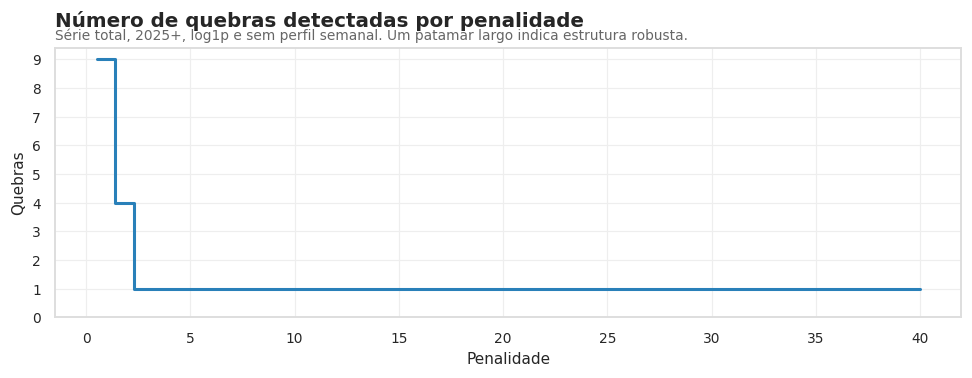

           min   max  count
n_quebras                  
9         0.50  0.50      1
4         1.40  1.40      1
1         2.30 40.00     43


In [149]:
# Série de trabalho: 2025 em diante, sem o regime-artefato.
serie_2025 = (
    fato_diario.loc[fato_diario["data"] >= Q_R2, ["data", "abertos_total"]]
    .reset_index(drop=True)
)
sinal_bruto = serie_2025["abertos_total"].to_numpy(dtype=float)
sinal_prep = preparar_sinal(sinal_bruto)

grade_pen = np.linspace(0.5, 40, 45)
curva = curva_penalidade(sinal_prep, grade_pen, min_size=21)

fig, ax = novo_grafico(
    "Número de quebras detectadas por penalidade",
    "Série total, 2025+, log1p e sem perfil semanal. Um patamar largo indica estrutura robusta.",
    figsize=(9, 3.6),
)
ax.step(curva["pen"], curva["n_quebras"], where="post", color=PALETA["destaque"], lw=2)
ax.set_xlabel("Penalidade")
ax.set_ylabel("Quebras")
ax.set_yticks(range(0, int(curva["n_quebras"].max()) + 1))
finalizar(fig)

print(curva.groupby("n_quebras")["pen"].agg(["min", "max", "count"]).sort_index(ascending=False))

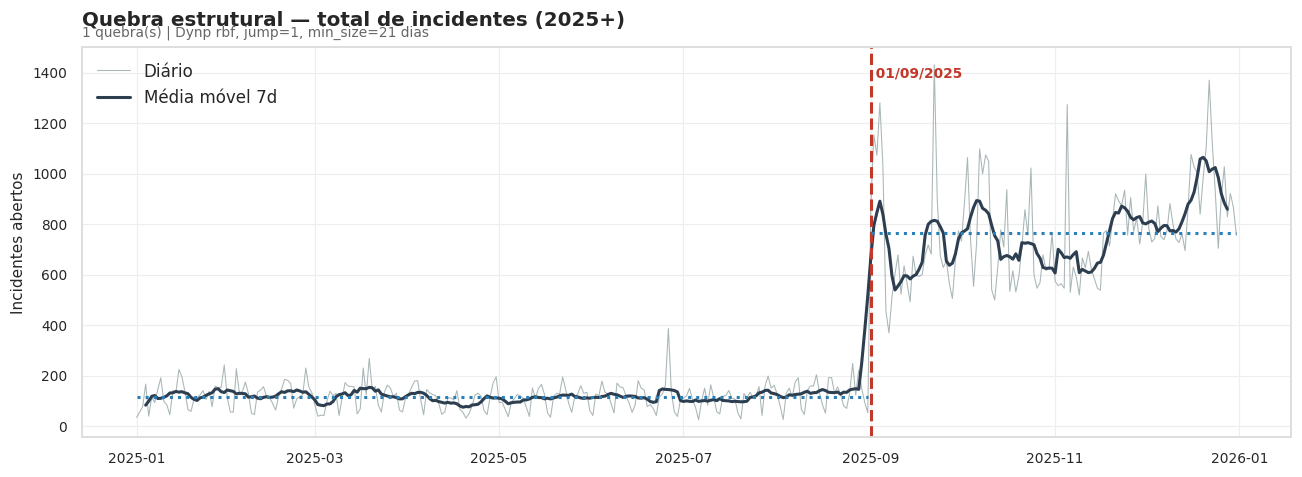

,bloco,inicio,fim,dias,media,mediana,desvio,razao_vs_anterior
0,1,2025-01-01,2025-08-31,243,116.82,120.00,51.18,NaN
1,2,2025-09-01,2025-12-31,122,765.76,735.50,201.78,6.55


In [150]:
def analisar_quebras(nome, serie_dias, valores, n_bkps=1, min_size=21):
    """Detecta, mede o efeito e desenha — em datas, não em índices."""
    sinal = preparar_sinal(valores)
    algo, pts = detectar_quebras(sinal, n_bkps=n_bkps, min_size=min_size)
    idx = pts[:-1]
    datas = [serie_dias.iloc[i] for i in idx]

    bordas = [0] + list(idx) + [len(sinal)]
    blocos = []
    for i in range(len(bordas) - 1):
        fatia = valores[bordas[i]:bordas[i + 1]]
        blocos.append({
            "bloco": i + 1,
            "inicio": serie_dias.iloc[bordas[i]],
            "fim": serie_dias.iloc[bordas[i + 1] - 1],
            "dias": len(fatia),
            "media": fatia.mean(),
            "mediana": np.median(fatia),
            "desvio": fatia.std(),
        })
    blocos = pd.DataFrame(blocos)
    blocos["razao_vs_anterior"] = (blocos["media"] / blocos["media"].shift(1)).round(2)

    fig, ax = novo_grafico(
        f"Quebra estrutural — {nome}",
        f"{n_bkps} quebra(s) | Dynp rbf, jump=1, min_size={min_size} dias",
    )
    ax.plot(serie_dias, valores, color=PALETA["neutro"], lw=0.7, alpha=0.8, label="Diário")
    ax.plot(serie_dias, pd.Series(valores).rolling(7, center=True).mean(),
            color=PALETA["total"], lw=2, label="Média móvel 7d")
    for d in datas:
        ax.axvline(d, color=PALETA["p2"], ls="--", lw=2)
        ax.annotate(f" {d:%d/%m/%Y}", (d, ax.get_ylim()[1] * 0.92),
                    color=PALETA["p2"], fontsize=9, weight="bold")
    for _, b in blocos.iterrows():
        ax.hlines(b["media"], b["inicio"], b["fim"], color=PALETA["destaque"], lw=2, ls=":")
    ax.set_ylabel("Incidentes abertos")
    ax.legend(loc="upper left")
    finalizar(fig)

    return datas, pts, sinal, algo, blocos


datas_q, pts_q, sinal_q, algo_q, blocos_q = analisar_quebras(
    "total de incidentes (2025+)", serie_2025["data"], sinal_bruto, n_bkps=1
)
blocos_q

Redução de custo observada     : 0.5951
Média sob a nula (200 permut.) : 0.0477
Máximo sob a nula              : 0.1737
p-valor por permutação         : 0.0050

Interpretação: o p-valor mede a chance de uma série SEM mudança de patamar,
mas com a mesma sazonalidade semanal, produzir um ganho tão grande.


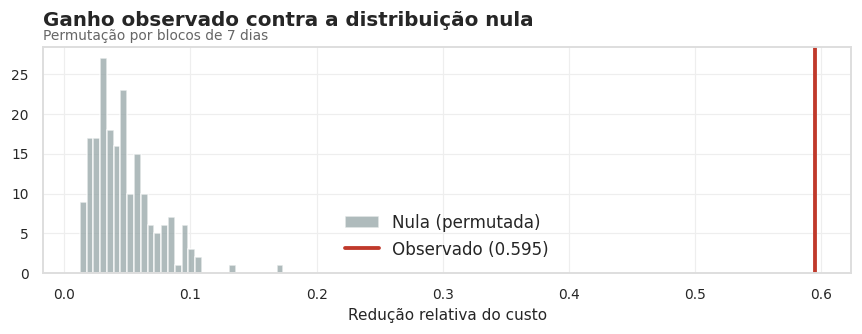

In [151]:
def teste_permutacao_quebra(sinal, n_bkps=1, min_size=21, n_perm=300, bloco=7, semente=42):
    """
    Testa o PROCEDIMENTO, não a quebra escolhida.

    Estatística: redução relativa do custo total ao permitir `n_bkps` quebras.
    Nula: a mesma série reordenada em blocos de 7 dias (permutação por blocos), o que preserva
    a autocorrelação de curto prazo e a sazonalidade semanal enquanto destrói a ordem de longo
    prazo — exatamente o que a hipótese "não há mudança de patamar" afirma.

    Isto resolve as duas fragilidades do Mann-Whitney aplicado depois da detecção: o ponto de
    corte deixa de ser escolhido nos mesmos dados em que é testado, e a autocorrelação deixa de
    inflar a significância.
    """
    rng = np.random.default_rng(semente)

    def ganho(x):
        algo = rpt.Dynp(model="rbf", min_size=min_size, jump=1).fit(x)
        pts = algo.predict(n_bkps=n_bkps)
        c_nulo = algo.cost.sum_of_costs([len(x)])
        return 1 - algo.cost.sum_of_costs(pts) / c_nulo if c_nulo > 0 else 0.0

    observado = ganho(sinal)

    n_blocos = int(np.ceil(len(sinal) / bloco))
    padded = np.pad(sinal, (0, n_blocos * bloco - len(sinal)), mode="wrap").reshape(n_blocos, bloco)

    nulos = []
    for _ in range(n_perm):
        emb = padded[rng.permutation(n_blocos)].ravel()[: len(sinal)]
        nulos.append(ganho(emb))
    nulos = np.array(nulos)

    p = (1 + (nulos >= observado).sum()) / (1 + n_perm)
    return observado, nulos, p


ganho_obs, ganho_nulo, p_valor = teste_permutacao_quebra(sinal_q, n_bkps=1, n_perm=200)

print(f"Redução de custo observada     : {ganho_obs:.4f}")
print(f"Média sob a nula (200 permut.) : {ganho_nulo.mean():.4f}")
print(f"Máximo sob a nula              : {ganho_nulo.max():.4f}")
print(f"p-valor por permutação         : {p_valor:.4f}")
print()
print("Interpretação: o p-valor mede a chance de uma série SEM mudança de patamar,")
print("mas com a mesma sazonalidade semanal, produzir um ganho tão grande.")

fig, ax = novo_grafico("Ganho observado contra a distribuição nula",
                       "Permutação por blocos de 7 dias", figsize=(8, 3.2))
ax.hist(ganho_nulo, bins=30, color=PALETA["neutro"], alpha=0.75, label="Nula (permutada)")
ax.axvline(ganho_obs, color=PALETA["p2"], lw=2.5, label=f"Observado ({ganho_obs:.3f})")
ax.set_xlabel("Redução relativa do custo")
ax.legend()
finalizar(fig)

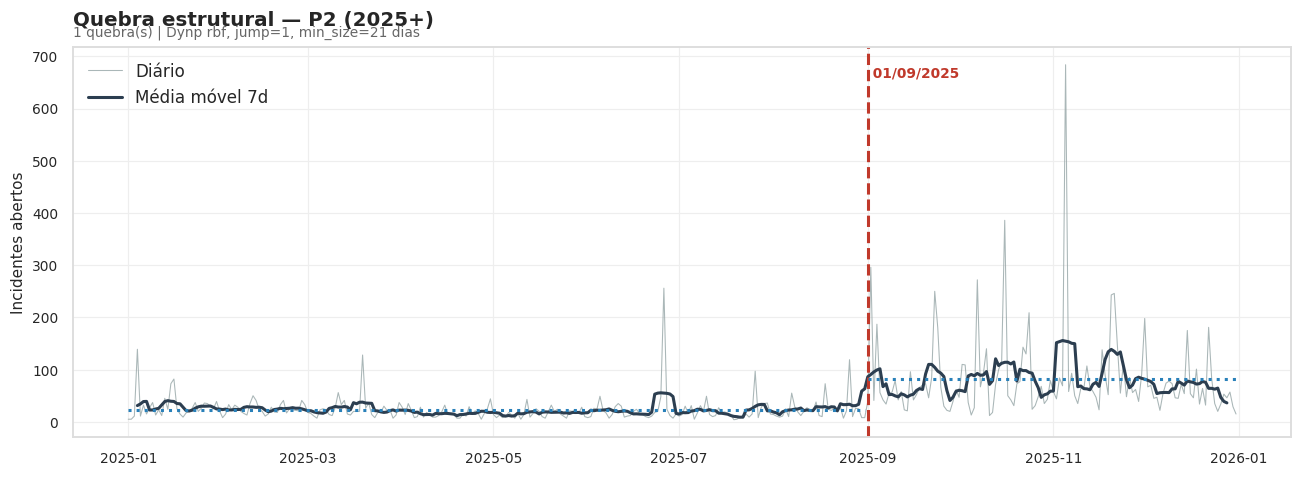

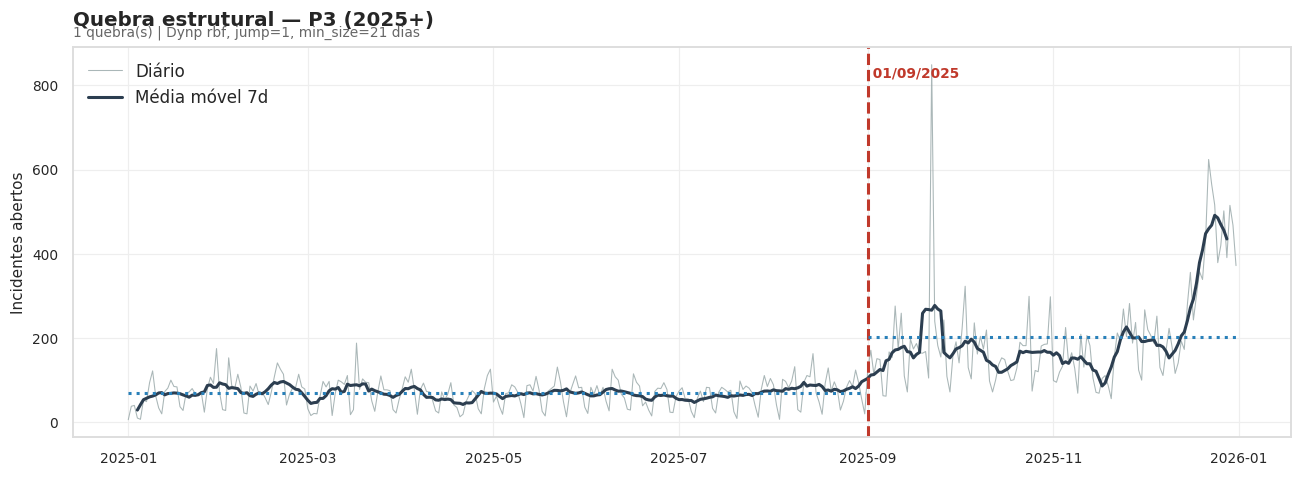

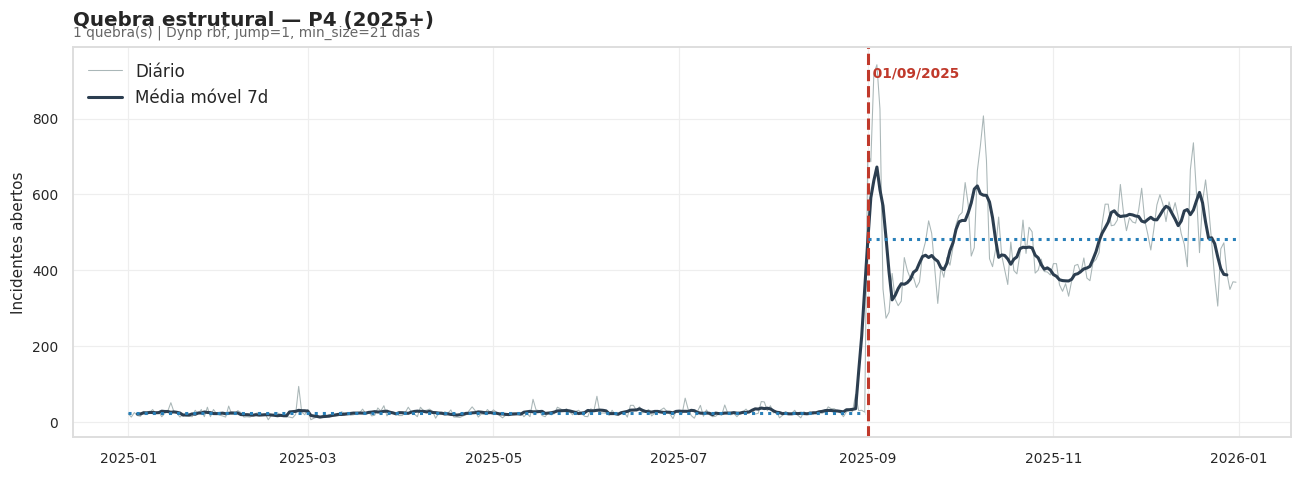

,prioridade,data_quebra,media_antes,media_depois,razao,p_permutacao
0,2,2025-09-01,23.21,82.01,3.53,0.00
1,3,2025-09-01,68.57,201.62,2.94,0.00
2,4,2025-09-01,23.79,481.97,20.26,0.00


In [152]:
# Cada prioridade tem sua própria quebra — e elas não coincidem exatamente.
resumo_quebras = []
for p in PRIORIDADES_ALVO:
    serie_p = fato_diario_prioridade.query("prioridade == @p and data >= @Q_R2").sort_values("data")
    datas_p, _, sinal_p, _, blocos_p = analisar_quebras(
        f"P{p} (2025+)", serie_p["data"].reset_index(drop=True),
        serie_p["abertos"].to_numpy(dtype=float), n_bkps=1,
    )
    _, _, p_val = teste_permutacao_quebra(sinal_p, n_bkps=1, n_perm=200)
    resumo_quebras.append({
        "prioridade": p,
        "data_quebra": datas_p[0],
        "media_antes": blocos_p.loc[0, "media"],
        "media_depois": blocos_p.loc[1, "media"],
        "razao": blocos_p.loc[1, "razao_vs_anterior"],
        "p_permutacao": p_val,
    })

pd.DataFrame(resumo_quebras)

## 3.2 O que explica a quebra de setembro

A quebra é grande demais para ser crescimento de demanda. Três cortes convergem para a mesma
explicação, e a consequência para o alvo é direta.

In [153]:
comparativo = (
    df[df["regime"].isin(REGIME_MODELAVEL)]
    .groupby("regime", observed=True)
    .agg(
        incidentes=("Número", "size"),
        dias=("data", "nunique"),
        pct_monitoramento=("aberto_por_monitoramento", lambda s: s.mean() * 100),
        pct_sem_intervencao=("sem_intervencao", lambda s: s.mean() * 100),
        duracao_mediana_h=("duracao_horas", "median"),
        duracao_media_h=("duracao_horas", "mean"),
        pct_sem_ic=("ic_ausente", lambda s: s.mean() * 100),
        pct_sem_classificacao=("sem_classificacao", lambda s: s.mean() * 100),
        ics_distintos=("ic", "nunique"),
    )
)
comparativo["media_dia"] = comparativo["incidentes"] / comparativo["dias"]
comparativo.T

regime,2,3
incidentes,"30,415.00","91,396.00"
dias,245.00,120.00
pct_monitoramento,57.55,94.76
pct_sem_intervencao,6.19,85.88
duracao_mediana_h,1.36,0.16
duracao_media_h,114.70,9.40
pct_sem_ic,0.41,1.81
pct_sem_classificacao,9.01,82.04
ics_distintos,"5,310.00","6,181.00"
media_dia,124.14,761.63


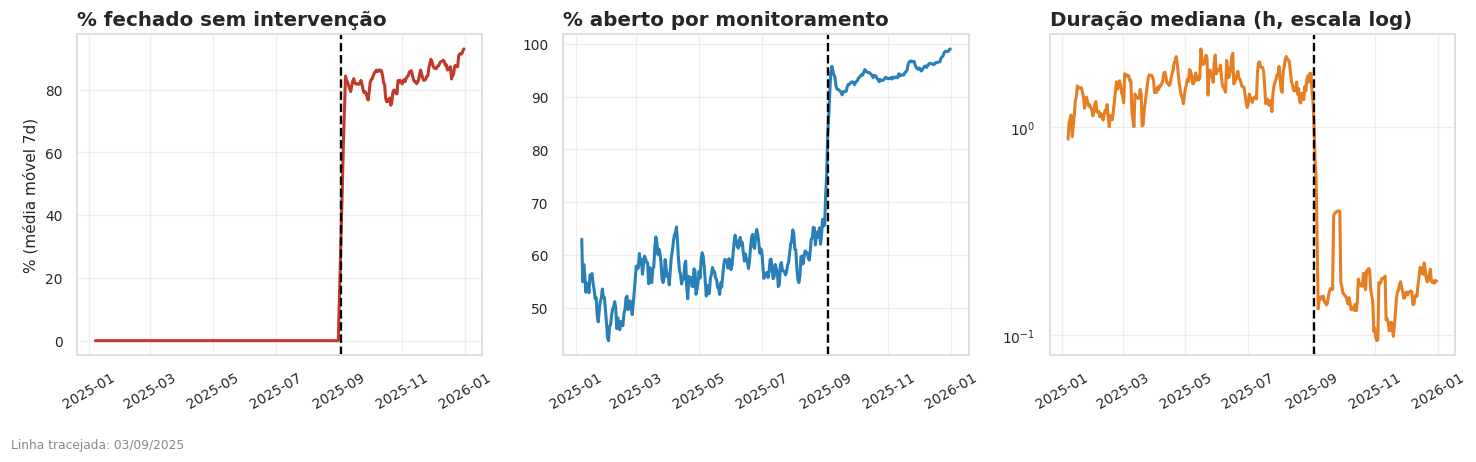

In [154]:
fig, axes = novo_grafico("Anatomia da quebra de setembro/2025", figsize=(13.5, 4), ncols=3)

serie = fato_diario[fato_diario["data"] >= Q_R2]

axes[0].plot(serie["data"], serie["taxa_sem_intervencao_total"].rolling(7).mean(),
             color=PALETA["p2"], lw=2)
axes[0].set_title("% fechado sem intervenção")
axes[0].set_ylabel("% (média móvel 7d)")

axes[1].plot(serie["data"], serie["taxa_monitoramento_total"].rolling(7).mean(),
             color=PALETA["destaque"], lw=2)
axes[1].set_title("% aberto por monitoramento")

dur = (
    df[df["regime"].isin(REGIME_MODELAVEL)]
    .groupby("data_encerrado", observed=True)["duracao_horas"].median()
)
axes[2].plot(dur.index, dur.rolling(7).mean(), color=PALETA["p3"], lw=2)
axes[2].set_yscale("log")
axes[2].set_title("Duração mediana (h, escala log)")

for ax in axes:
    ax.axvline(Q_R3, color="black", ls="--", lw=1.5)
    ax.tick_params(axis="x", rotation=30)
finalizar(fig, "Linha tracejada: 03/09/2025")

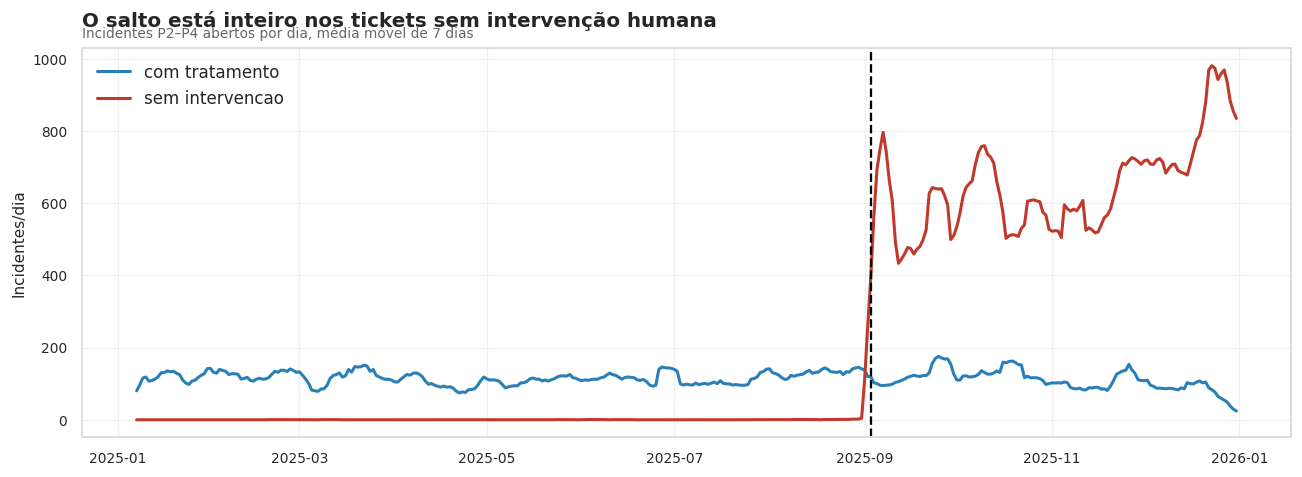

tipo,com_tratamento,sem_intervencao,fator_r3_r2
regime,,,
2,115.21,47.08,NaN
3,107.42,654.05,NaN


In [155]:
# A pergunta operacional: se os tickets 'Sem Intervenção' saírem, o que sobra do salto?
por_tipo = (
    df[df["prioridade"].isin(PRIORIDADES_ALVO)]
    .assign(tipo=lambda d: np.where(d["sem_intervencao"] == 1, "sem_intervencao", "com_tratamento"))
    .groupby(["data", "tipo"], observed=True).size().rename("abertos").reset_index()
)

fig, ax = novo_grafico(
    "O salto está inteiro nos tickets sem intervenção humana",
    "Incidentes P2–P4 abertos por dia, média móvel de 7 dias",
)
for tipo, cor in [("com_tratamento", PALETA["destaque"]), ("sem_intervencao", PALETA["p2"])]:
    s = por_tipo[por_tipo["tipo"] == tipo].set_index("data")["abertos"].asfreq("D").fillna(0)
    s = s[s.index >= Q_R2]
    ax.plot(s.index, s.rolling(7).mean(), lw=2, color=cor, label=tipo.replace("_", " "))
ax.axvline(Q_R3, color="black", ls="--", lw=1.5)
ax.set_ylabel("Incidentes/dia")
ax.legend()
finalizar(fig)

razao = (
    por_tipo.assign(regime=np.select([por_tipo["data"] < Q_R2, por_tipo["data"] < Q_R3], [1, 2], default=3))
    .query("regime in @REGIME_MODELAVEL")
    .groupby(["regime", "tipo"], observed=True)["abertos"].mean().unstack()
)
razao["fator_r3_r2"] = (razao.loc[3] / razao.loc[2]).round(2) if 2 in razao.index and 3 in razao.index else np.nan
razao

> **Decisão que precisa ser tomada antes da modelagem.**
>
> Se o alvo incluir os tickets `Sem Intervenção`, o modelo vai prever majoritariamente o *volume
> de alertas de um pipeline automático* — que responde a mudanças de configuração de
> monitoramento, não à saúde da plataforma. É previsível (é máquina), mas responde a uma pergunta
> de capacidade que talvez não seja a que a área quer.
>
> Se o alvo excluir esses tickets, ele passa a medir a carga que chega a uma pessoa — provavelmente
> mais próxima da intenção original — mas o histórico útil encolhe e a série fica mais rala.
>
> A recomendação é **modelar as duas e apresentar as duas**, porque a série "com tratamento" é a
> que sustenta decisão de escala e a "sem intervenção" é a que domina a contagem bruta. Não é uma
> escolha técnica; é uma escolha de qual pergunta está sendo respondida.

## 3.3 Sazonalidade

Comparações sempre entre R2 e R3, nunca contra R1 — R1 não é um regime de negócio.

O que se mede aqui é **razão**, não diferença: quanto o volume de R3 é maior que o de R2 em cada
recorte. Um crescimento uniforme daria a mesma razão em todos os cortes. Onde a razão desvia, há
informação sobre a *natureza* da mudança.

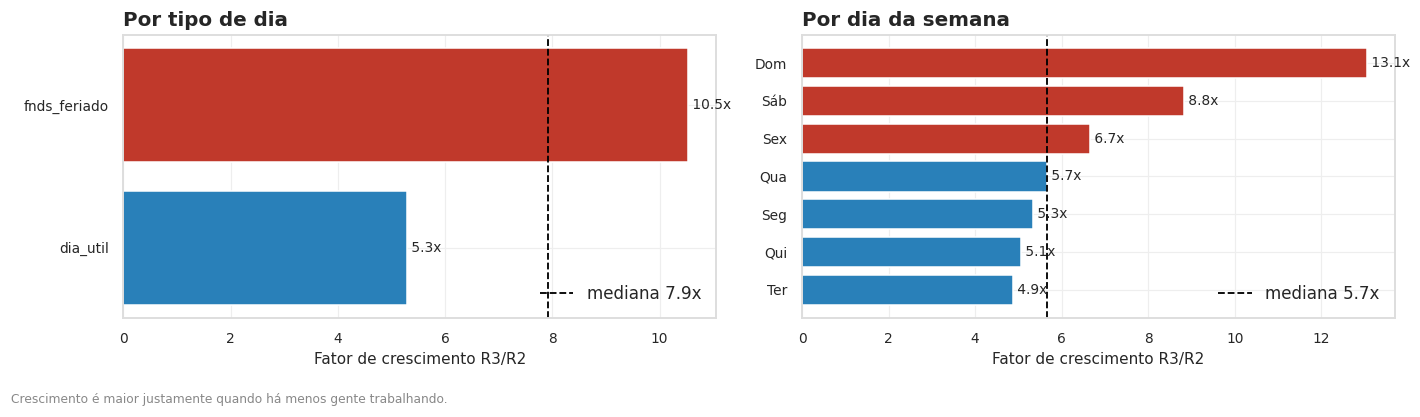

In [156]:
def fator_crescimento(dados, dimensao, valor="abertos", regimes=(2, 3)):
    """Média diária por categoria em cada regime + a razão entre eles."""
    tab = (
        dados[dados["regime"].isin(regimes)]
        .groupby(["regime", dimensao], observed=True)[valor].mean()
        .unstack("regime")
        .rename(columns=lambda r: f"R{r}")
    )
    tab["fator"] = (tab[f"R{regimes[1]}"] / tab[f"R{regimes[0]}"]).round(2)
    return tab.sort_values("fator")


def grafico_fator(tab, titulo, subtitulo=None, ax=None):
    criado = ax is None
    if criado:
        fig, ax = novo_grafico(titulo, subtitulo, figsize=(8, 3.4))
    else:
        ax.set_title(titulo)
    cores = [PALETA["p2"] if v > tab["fator"].median() else PALETA["destaque"] for v in tab["fator"]]
    ax.barh(tab.index.astype(str), tab["fator"], color=cores)
    ax.axvline(tab["fator"].median(), color="black", ls="--", lw=1.2,
               label=f"mediana {tab['fator'].median():.1f}x")
    for i, v in enumerate(tab["fator"]):
        ax.text(v, i, f" {v:.1f}x", va="center", fontsize=9)
    ax.set_xlabel("Fator de crescimento R3/R2")
    ax.legend(loc="lower right")
    if criado:
        finalizar(fig)
    return ax


base_dia = fato_diario_prioridade.merge(
    dim_calendario[["data", "tipo_dia", "nome_dia_semana", "dia_semana"]], on="data", how="left"
)
diario_total = base_dia.groupby(["data", "regime", "tipo_dia", "nome_dia_semana", "dia_semana"],
                                observed=True)["abertos"].sum().reset_index()

fig, axes = novo_grafico("Onde o crescimento se concentrou", figsize=(13, 3.6), ncols=2)
grafico_fator(fator_crescimento(diario_total, "tipo_dia"), "Por tipo de dia", ax=axes[0])
sem = fator_crescimento(diario_total.sort_values("dia_semana"), "nome_dia_semana")
grafico_fator(sem, "Por dia da semana", ax=axes[1])
finalizar(fig, "Crescimento é maior justamente quando há menos gente trabalhando.")

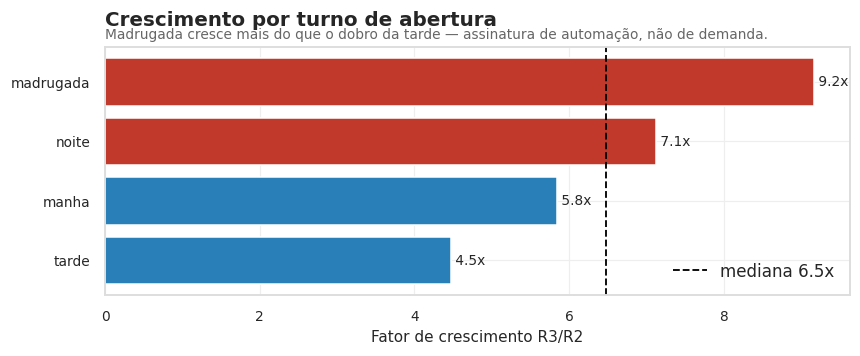

regime,R2,R3,fator
turno,,,
tarde,42.16,188.94,4.48
manha,34.75,202.81,5.84
noite,25.44,181.32,7.13
madrugada,20.53,188.40,9.17


In [157]:
turno_total = (
    fato_diario_prioridade_turno.groupby(["data", "regime", "turno"], observed=True)["abertos"]
    .sum().reset_index()
)
tab_turno = fator_crescimento(turno_total, "turno")
grafico_fator(
    tab_turno, "Crescimento por turno de abertura",
    "Madrugada cresce mais do que o dobro da tarde — assinatura de automação, não de demanda.",
)
tab_turno

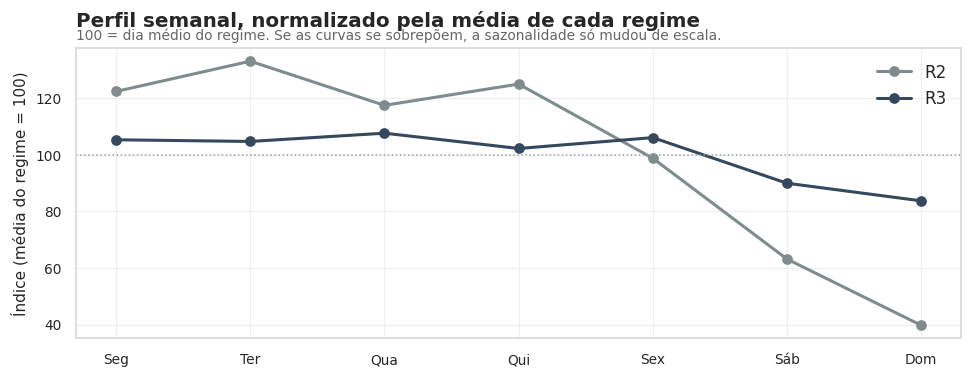

regime,2,3
nome_dia_semana,,
Dom,39.70,83.80
Qua,117.50,107.70
Qui,125.10,102.30
Seg,122.50,105.40
Sex,98.80,106.10
Sáb,63.20,90.00
Ter,133.20,104.80


In [158]:
# O perfil semanal mudou de forma, não só de escala? Normalizando cada regime pela própria média.
perfil = (
    diario_total[diario_total["regime"].isin(REGIME_MODELAVEL)]
    .groupby(["regime", "dia_semana", "nome_dia_semana"], observed=True)["abertos"].mean()
    .reset_index()
)
perfil["indice"] = perfil["abertos"] / perfil.groupby("regime")["abertos"].transform("mean") * 100

fig, ax = novo_grafico(
    "Perfil semanal, normalizado pela média de cada regime",
    "100 = dia médio do regime. Se as curvas se sobrepõem, a sazonalidade só mudou de escala.",
    figsize=(9, 3.6),
)
for r, cor in [(2, PALETA["r2"]), (3, PALETA["r3"])]:
    sub = perfil[perfil["regime"] == r].sort_values("dia_semana")
    ax.plot(sub["nome_dia_semana"], sub["indice"], marker="o", lw=2, color=cor, label=f"R{r}")
ax.axhline(100, color=PALETA["neutro"], ls=":", lw=1)
ax.set_ylabel("Índice (média do regime = 100)")
ax.legend()
finalizar(fig)

perfil.pivot(index="nome_dia_semana", columns="regime", values="indice").round(1)

O achatamento da curva em R3 é a evidência mais limpa de automação: o alerta automático não sabe
que é domingo. Para a modelagem isso significa que **`dia_semana` perdeu poder preditivo em R3** —
uma feature calibrada em R2 vai carregar uma sazonalidade que já não existe. Vale testar o modelo
com e sem os termos semanais.

## 3.4 Prioridade

A recomposição do mix é o segundo achado que condiciona a modelagem.

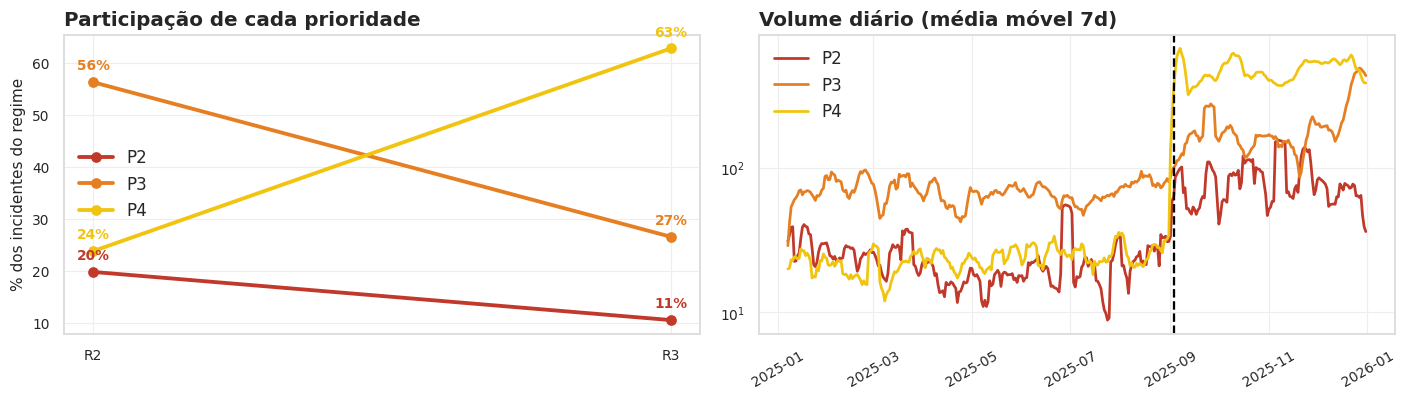

regime,2,3
prioridade,,
2,19.80,10.60
3,56.30,26.60
4,23.80,62.80


In [159]:
mix = (
    fato_diario_prioridade[fato_diario_prioridade["regime"].isin(REGIME_MODELAVEL)]
    .groupby(["regime", "prioridade"], observed=True)["abertos"].sum().reset_index()
)
mix["pct"] = mix["abertos"] / mix.groupby("regime")["abertos"].transform("sum") * 100

fig, axes = novo_grafico("Prioridade: recomposição do mix", figsize=(13, 3.8), ncols=2)

for p in PRIORIDADES_ALVO:
    sub = mix[mix["prioridade"] == p]
    axes[0].plot([f"R{r}" for r in sub["regime"]], sub["pct"], marker="o", lw=2.5,
                 color=COR_PRIORIDADE[p], label=f"P{p}")
    for _, linha in sub.iterrows():
        axes[0].annotate(f"{linha['pct']:.0f}%", (f"R{int(linha['regime'])}", linha["pct"]),
                         textcoords="offset points", xytext=(0, 8), ha="center",
                         color=COR_PRIORIDADE[p], fontsize=9, weight="bold")
axes[0].set_title("Participação de cada prioridade")
axes[0].set_ylabel("% dos incidentes do regime")
axes[0].legend()

serie_p = fato_diario_prioridade[fato_diario_prioridade["data"] >= Q_R2]
for p in PRIORIDADES_ALVO:
    sub = serie_p[serie_p["prioridade"] == p]
    axes[1].plot(sub["data"], sub["abertos"].rolling(7).mean(), lw=1.8,
                 color=COR_PRIORIDADE[p], label=f"P{p}")
axes[1].axvline(Q_R3, color="black", ls="--", lw=1.5)
axes[1].set_title("Volume diário (média móvel 7d)")
axes[1].set_yscale("log")
axes[1].tick_params(axis="x", rotation=30)
axes[1].legend()
finalizar(fig)

mix.pivot(index="prioridade", columns="regime", values="pct").round(1)

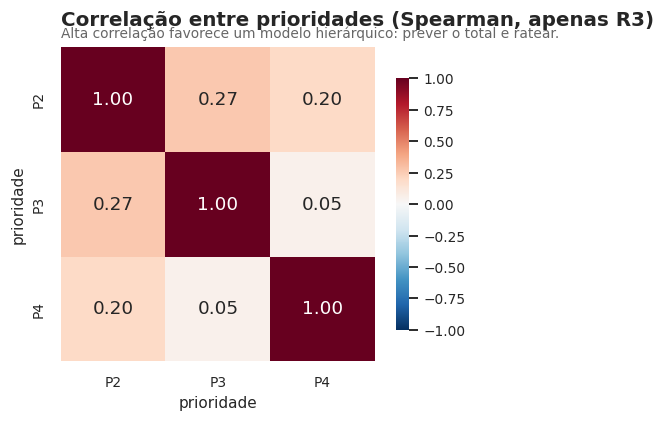

In [160]:
# As três séries se movem juntas? Se a correlação for alta, um modelo do total + rateio pode
# render mais que três modelos independentes, dado o histórico curto.
largo_p = (
    fato_diario_prioridade.query("regime == 3")
    .pivot(index="data", columns="prioridade", values="abertos")
    .rename(columns=lambda p: f"P{p}")
)
corr = largo_p.corr(method="spearman")

fig, ax = novo_grafico("Correlação entre prioridades (Spearman, apenas R3)",
                       "Alta correlação favorece um modelo hierárquico: prever o total e ratear.",
                       figsize=(5.2, 4))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            square=True, cbar_kws={"shrink": 0.8}, ax=ax)
finalizar(fig)

## 3.5 Grupo designado — a primeira lacuna

Você indicou 14 times; a coluna tem **17 valores distintos**. A leitura abaixo começa por essa
reconciliação, porque ela muda o que "um time" significa na modelagem.

A pergunta que orienta a seção é a que você formulou: **por que cada incidente vai para cada
time?** As quatro respostas parciais estão em ranking, especialização, cobertura horária e
resposta à quebra.

In [161]:
resumo_times = (
    dim_time_regime.groupby("time", observed=True)
    .agg(
        incidentes=("incidentes", "sum"),
        primeira_data=("primeira_data", "min"),
        ultima_data=("ultima_data", "max"),
        regimes_ativos=("regime", "nunique"),
    )
    .reset_index()
    .sort_values("incidentes", ascending=False)
)
resumo_times["pct_total"] = resumo_times["incidentes"] / resumo_times["incidentes"].sum() * 100
resumo_times["pct_acumulado"] = resumo_times["pct_total"].cumsum()
resumo_times["dias_desde_ultimo"] = (df["data"].max() - resumo_times["ultima_data"]).dt.days
resumo_times["situacao"] = np.select(
    [resumo_times["incidentes"] < 50,
     resumo_times["dias_desde_ultimo"] > 60,
     resumo_times["pct_total"] >= 1],
    ["residual", "inativo", "relevante"], default="marginal",
)

print(f"Grupos distintos na base : {resumo_times['time'].nunique()}")
print(resumo_times["situacao"].value_counts().to_string())
print()
print(f"Times que somam 99% do volume: "
      f"{(resumo_times['pct_acumulado'] < 99).sum() + 1}")
resumo_times

Grupos distintos na base : 17
situacao
marginal     10
relevante     6
residual      1

Times que somam 99% do volume: 10


,time,incidentes,primeira_data,ultima_data,regimes_ativos,pct_total,pct_acumulado,dias_desde_ultimo,situacao
13,Team14,92775,2023-01-09,2025-12-31,3,75.71,75.71,0,relevante
10,Team11,9790,2023-01-11,2025-12-30,3,7.99,83.70,1,relevante
4,Team05,9276,2023-01-30,2025-12-30,3,7.57,91.27,1,relevante
8,Team09,3425,2023-02-09,2025-12-31,3,2.79,94.06,0,relevante
11,Team12,2173,2024-03-19,2025-12-31,3,1.77,95.83,0,relevante
2,Team03,1306,2024-11-19,2025-12-31,3,1.07,96.90,0,relevante
9,Team10,1172,2024-12-24,2025-12-31,3,0.96,97.86,0,marginal
16,Team17,743,2023-05-20,2025-12-26,3,0.61,98.46,5,marginal
1,Team02,579,2023-08-30,2025-12-30,3,0.47,98.94,1,marginal
0,Team01,306,2024-12-29,2025-12-26,3,0.25,99.19,5,marginal


**Reconciliação.** A diferença entre 17 e 14 não é erro de cadastro: alguns grupos são residuais
(Team13 com 1 incidente, Team06 com 50) ou pararam de receber incidentes. Se a lista oficial de
14 times é a que vale, os três excedentes são filas legadas ou de exceção.

Para a modelagem, o número que importa é outro: **quantos times realmente movem o volume**. A
coluna `pct_acumulado` responde isso — e a resposta é bem menos que 14.

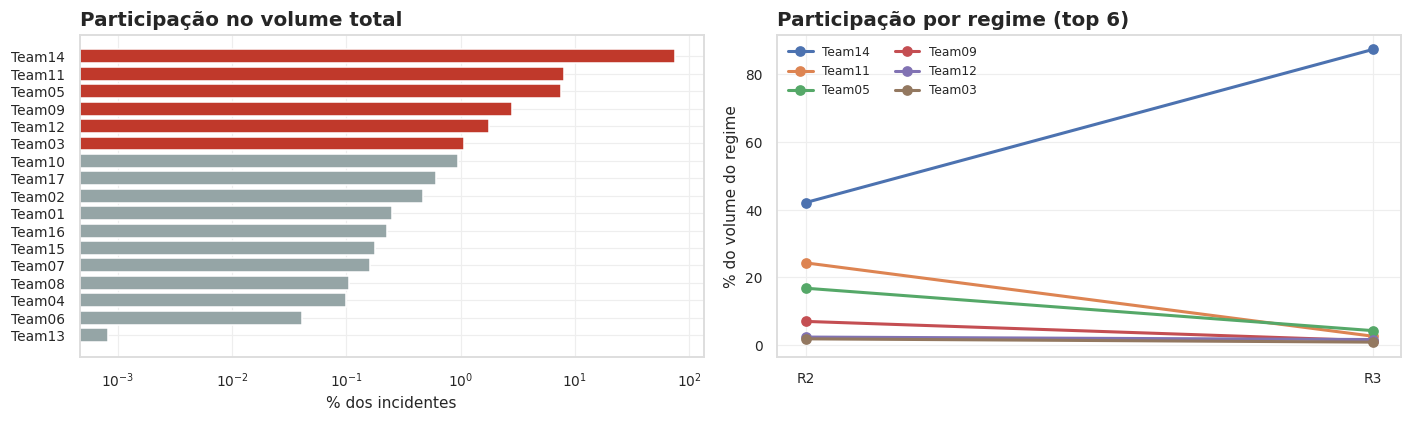

In [162]:
top_times = resumo_times.head(6)["time"].tolist()

fig, axes = novo_grafico("Concentração e evolução da carga entre times", figsize=(13, 4), ncols=2)

axes[0].barh(resumo_times["time"][::-1], resumo_times["pct_total"][::-1],
             color=[PALETA["p2"] if t in top_times else PALETA["neutro"]
                    for t in resumo_times["time"][::-1]])
axes[0].set_title("Participação no volume total")
axes[0].set_xlabel("% dos incidentes")
axes[0].set_xscale("log")

share = dim_time_regime[dim_time_regime["regime"].isin(REGIME_MODELAVEL)]
for t in top_times:
    sub = share[share["time"] == t].sort_values("regime")
    axes[1].plot([f"R{r}" for r in sub["regime"]], sub["share_regime"], marker="o", lw=2, label=t)
axes[1].set_title("Participação por regime (top 6)")
axes[1].set_ylabel("% do volume do regime")
axes[1].legend(fontsize=8, ncol=2)
finalizar(fig)

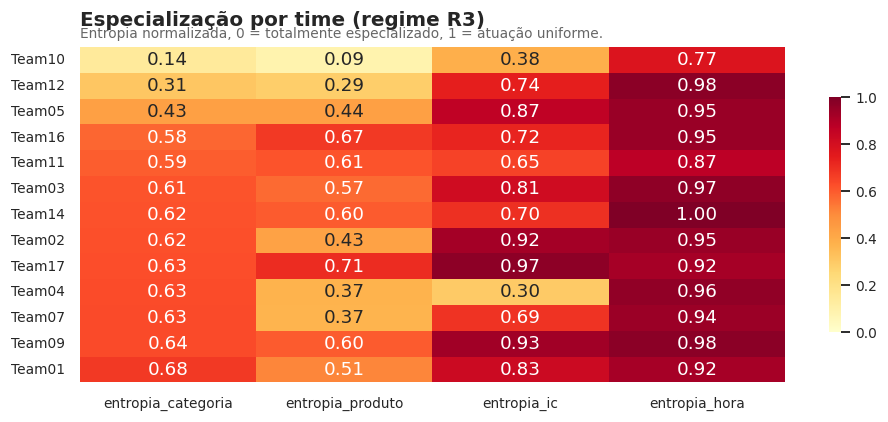

In [163]:
# Especialização: entropia baixa = o time atende poucas categorias; alta = generalista.
esp = (
    dim_time_regime.query("regime == 3 and incidentes >= 50")
    .set_index("time")[["entropia_categoria", "entropia_produto", "entropia_ic", "entropia_hora"]]
    .sort_values("entropia_categoria")
    .astype(float)
)

fig, ax = novo_grafico(
    "Especialização por time (regime R3)",
    "Entropia normalizada, 0 = totalmente especializado, 1 = atuação uniforme.",
    figsize=(9, 4),
)
sns.heatmap(esp, annot=True, fmt=".2f", cmap="YlOrRd", vmin=0, vmax=1,
            cbar_kws={"shrink": 0.7}, ax=ax)
ax.set_ylabel("")
finalizar(fig)

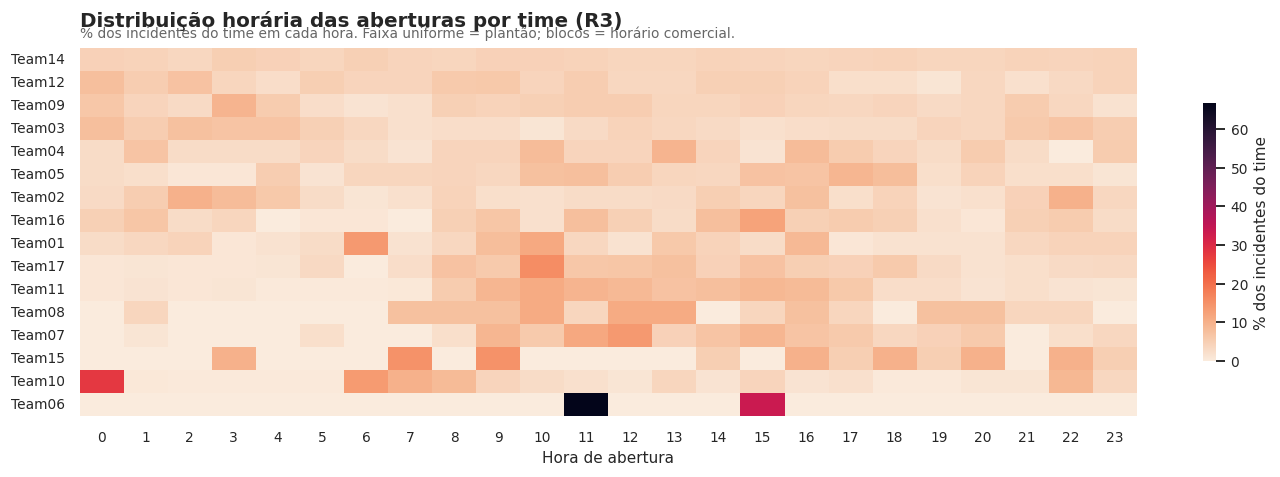

,horas_cobertas,pct_madrugada_0a6,pct_comercial_8a18,uniformidade
Grupo designado,,,,
Team03,24,39.50,29.50,0.53
Team10,24,30.10,31.20,-0.49
Team02,24,35.50,39.80,0.39
Team15,11,10.00,45.00,-0.26
Team14,24,25.50,45.40,0.91
Team12,24,31.40,46.50,0.61
Team09,24,30.90,48.00,0.59
Team01,24,15.80,52.60,0.20
Team04,23,21.90,57.50,0.45


In [164]:
# Cobertura horária: quem é plantão 24x7 e quem é horário comercial.
hora_time = (
    df.query("regime == 3")
    .groupby(["Grupo designado", "hora_abertura"], observed=True).size()
    .rename("inc").reset_index()
)
hora_time["pct"] = (
    hora_time["inc"] / hora_time.groupby("Grupo designado")["inc"].transform("sum") * 100
)
mapa_hora = hora_time.pivot(index="Grupo designado", columns="hora_abertura", values="pct")
mapa_hora = mapa_hora.loc[mapa_hora.index.isin(resumo_times.query("incidentes >= 50")["time"])]
mapa_hora = mapa_hora.reindex(columns=range(24)).fillna(0)
mapa_hora = mapa_hora.loc[mapa_hora.std(axis=1).sort_values().index]

fig, ax = novo_grafico(
    "Distribuição horária das aberturas por time (R3)",
    "% dos incidentes do time em cada hora. Faixa uniforme = plantão; blocos = horário comercial.",
    figsize=(13, 4.5),
)
sns.heatmap(mapa_hora, cmap="rocket_r", cbar_kws={"label": "% dos incidentes do time", "shrink": 0.7}, ax=ax)
ax.set_xlabel("Hora de abertura")
ax.set_ylabel("")
finalizar(fig)

pd.DataFrame({
    "horas_cobertas": (mapa_hora > 0).sum(axis=1),
    "pct_madrugada_0a6": mapa_hora.loc[:, 0:5].sum(axis=1).round(1),
    "pct_comercial_8a18": mapa_hora.loc[:, 8:18].sum(axis=1).round(1),
    "uniformidade": (1 - mapa_hora.std(axis=1) / mapa_hora.mean(axis=1)).round(2),
}).sort_values("pct_comercial_8a18")

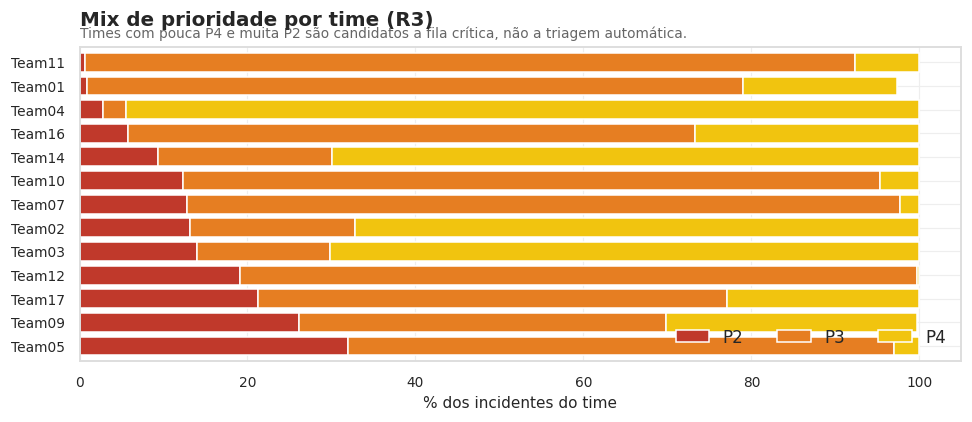

,P2,P3,P4
time,,,
Team05,32.00,65.10,3.00
Team09,26.10,43.70,30.00
Team17,21.20,55.80,22.90
Team12,19.10,80.60,0.30
Team03,14.00,15.80,70.20
Team02,13.10,19.70,67.20
Team07,12.80,84.90,2.30
Team10,12.30,83.00,4.70
Team14,9.40,20.70,69.90


In [165]:
# Mix de prioridade por time — os times atendem as mesmas prioridades?
mix_time = (
    dim_time_regime.query("regime == 3 and incidentes >= 50")
    .set_index("time")[[f"pct_p{p}" for p in PRIORIDADES_ALVO]]
    .rename(columns=lambda c: c.upper().replace("PCT_", ""))
)
mix_time = mix_time.loc[mix_time["P2"].sort_values(ascending=False).index]

fig, ax = novo_grafico(
    "Mix de prioridade por time (R3)",
    "Times com pouca P4 e muita P2 são candidatos a fila crítica, não a triagem automática.",
    figsize=(9, 4),
)
mix_time.plot(kind="barh", stacked=True, ax=ax,
              color=[COR_PRIORIDADE[p] for p in PRIORIDADES_ALVO], width=0.8)
ax.set_xlabel("% dos incidentes do time")
ax.set_ylabel("")
ax.legend(title="", ncol=3, loc="lower right")
finalizar(fig)
mix_time.round(1)

In [166]:
def correlacao_defasada(serie_x, serie_y, defasagens=range(0, 8)):
    """Correlação de Spearman de x(t-k) contra y(t). k>0 => x antecede y."""
    return pd.DataFrame([
        {"defasagem": k, "correlacao": serie_x.shift(k).corr(serie_y, method="spearman")}
        for k in defasagens
    ])


# Algum time funciona como indicador antecedente do volume de P2/P3?
alvo_p2p3 = (
    fato_diario_prioridade.query("regime == 3 and prioridade in [2, 3]")
    .groupby("data", observed=True)["abertos"].sum()
)
lead = []
for t in resumo_times.query("incidentes >= 200")["time"]:
    s = (
        fato_diario_time.query("regime == 3 and time == @t")
        .set_index("data")["abertos"].reindex(alvo_p2p3.index).fillna(0)
    )
    c = correlacao_defasada(s, alvo_p2p3)
    melhor = c.loc[c["correlacao"].abs().idxmax()]
    lead.append({"time": t, "melhor_defasagem": int(melhor["defasagem"]),
                 "correlacao": round(melhor["correlacao"], 3),
                 "correlacao_lag0": round(c.loc[0, "correlacao"], 3)})

pd.DataFrame(lead).sort_values("correlacao", key=abs, ascending=False)

,time,melhor_defasagem,correlacao,correlacao_lag0
0,Team14,0,0.64,0.64
1,Team11,3,-0.39,0.28
2,Team05,0,0.36,0.36
3,Team09,0,0.32,0.32
10,Team16,3,-0.25,-0.03
4,Team12,3,-0.24,0.01
6,Team10,0,0.23,0.23
5,Team03,2,0.22,0.22
8,Team02,7,0.21,0.05
7,Team17,7,0.18,0.13


**Leitura para a modelagem.** Se algum time apresenta correlação máxima em defasagem ≥ 1, a série
dele é candidata a feature antecedente — o que é mais útil que a correlação contemporânea, já que
esta última não está disponível no momento da previsão. Times cuja melhor defasagem é 0 são
apenas espelho do volume total e não acrescentam informação.

## 3.6 Item de configuração

O achado central se sustenta e vale repetir com o número: **em R3, 16 % dos ICs ativos concentram
89 % dos incidentes.** Uma feature baseada na média da base inteira descreveria um IC que não
existe. O que carrega sinal é a cauda.

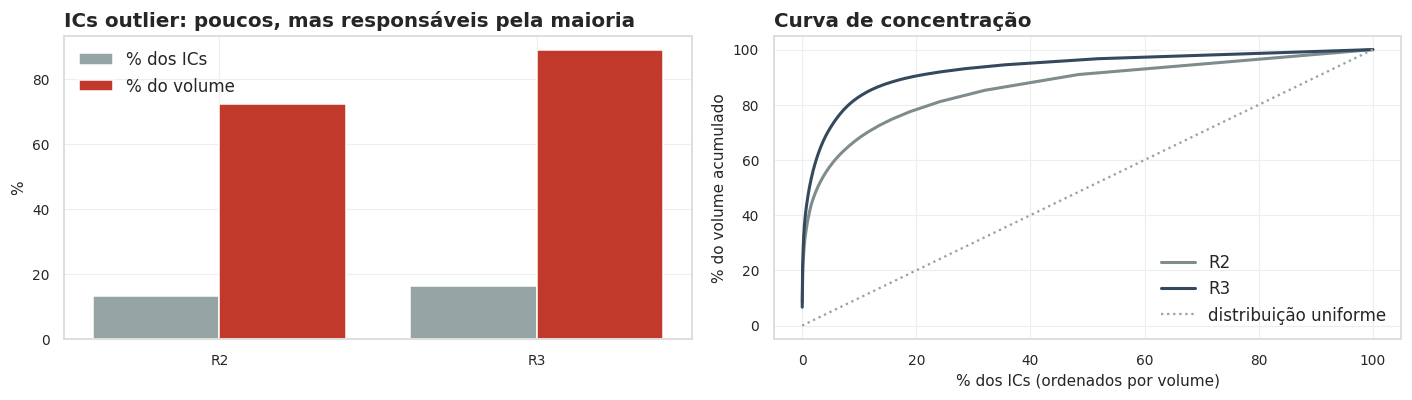

,regime,ics_ativos,limite_outlier,ics_outliers,pct_ics_outliers,pct_volume_outliers
0,R2,5309,6.00,703,13.24,72.22
1,R3,6180,8.50,1021,16.52,88.76


In [167]:
conc = []
for r in REGIME_MODELAVEL:
    sub = dim_ic_regime.query("regime == @r and incidentes > 0")
    li, ls = limites_iqr(sub["incidentes"])
    outliers = sub[sub["incidentes"] > ls]
    conc.append({
        "regime": f"R{r}",
        "ics_ativos": len(sub),
        "limite_outlier": ls,
        "ics_outliers": len(outliers),
        "pct_ics_outliers": len(outliers) / len(sub) * 100,
        "pct_volume_outliers": outliers["incidentes"].sum() / sub["incidentes"].sum() * 100,
    })
conc = pd.DataFrame(conc)

fig, axes = novo_grafico("Concentração do volume em poucos ICs", figsize=(13, 3.8), ncols=2)

x = np.arange(len(conc))
axes[0].bar(x - 0.2, conc["pct_ics_outliers"], 0.4, color=PALETA["neutro"], label="% dos ICs")
axes[0].bar(x + 0.2, conc["pct_volume_outliers"], 0.4, color=PALETA["p2"], label="% do volume")
axes[0].set_xticks(x, conc["regime"])
axes[0].set_title("ICs outlier: poucos, mas responsáveis pela maioria")
axes[0].set_ylabel("%")
axes[0].legend()

for r, cor in [(2, PALETA["r2"]), (3, PALETA["r3"])]:
    sub = dim_ic_regime.query("regime == @r and incidentes > 0").sort_values("incidentes", ascending=False)
    cum = sub["incidentes"].cumsum() / sub["incidentes"].sum() * 100
    axes[1].plot(np.arange(1, len(sub) + 1) / len(sub) * 100, cum, lw=2, color=cor, label=f"R{r}")
axes[1].plot([0, 100], [0, 100], ls=":", color=PALETA["neutro"], label="distribuição uniforme")
axes[1].set_title("Curva de concentração")
axes[1].set_xlabel("% dos ICs (ordenados por volume)")
axes[1].set_ylabel("% do volume acumulado")
axes[1].legend()
finalizar(fig)

conc.round(2)

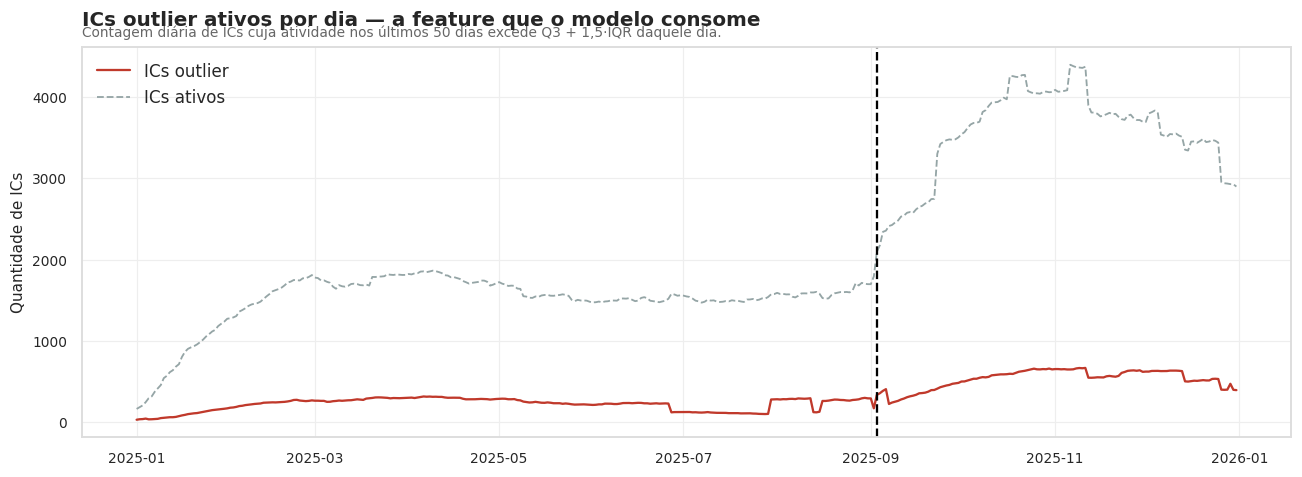

,ics,pct
jornada_monitoramento,,
Monitorado nativo novo,3198,34.90
Monitorado nativo antigo,3110,33.90
Sempre manual,2100,22.90
Migrado no R3,602,6.60
Regrediu para manual,122,1.30
Migrado no R2,32,0.30
Oscilante (termina monitorado),7,0.10


In [168]:
fig, ax = novo_grafico(
    "ICs outlier ativos por dia — a feature que o modelo consome",
    "Contagem diária de ICs cuja atividade nos últimos 50 dias excede Q3 + 1,5·IQR daquele dia.",
)
sub = ft_ic[ft_ic["data"] >= Q_R2]
ax.plot(sub["data"], sub["ics_outliers"], color=PALETA["p2"], lw=1.5, label="ICs outlier")
ax.plot(sub["data"], sub["ics_ativos"], color=PALETA["neutro"], lw=1.2, ls="--", label="ICs ativos")
ax.axvline(Q_R3, color="black", ls="--", lw=1.5)
ax.set_ylabel("Quantidade de ICs")
ax.legend()
finalizar(fig)

dim_ic["jornada_monitoramento"].value_counts().rename("ics").to_frame().assign(
    pct=lambda d: (d["ics"] / d["ics"].sum() * 100).round(1)
)

In [169]:
# Os 63% de nulo em Produto/Categoria/Subcategoria são aleatórios?
nulos = (
    df.groupby(["regime", "sem_classificacao"], observed=True)
    .agg(incidentes=("Número", "size"),
         pct_monitoramento=("aberto_por_monitoramento", lambda s: s.mean() * 100),
         pct_sem_intervencao=("sem_intervencao", lambda s: s.mean() * 100),
         duracao_mediana_h=("duracao_horas", "median"))
    .reset_index()
)
nulos["pct_do_regime"] = (
    nulos["incidentes"] / nulos.groupby("regime")["incidentes"].transform("sum") * 100
)
nulos.round(2)

,regime,sem_classificacao,incidentes,pct_monitoramento,pct_sem_intervencao,duracao_mediana_h,pct_do_regime
0,1,0,732,26.37,0.41,"4,186.91",100.00
1,2,0,27675,53.34,0.24,1.51,90.99
2,2,1,2740,100.00,66.28,0.26,9.01
3,3,0,16419,70.81,27.58,1.24,17.96
4,3,1,74977,100.00,98.64,0.09,82.04


Se `sem_classificacao = 1` concentrar aberturas por monitoramento e duração muito curta, então a
ausência de `Produto`/`Categoria`/`Subcategoria` é **estrutural**: o pipeline automático não
preenche esses campos. Nesse caso as três colunas não são candidatas a feature do modelo diário —
elas só descrevem o subconjunto manual. O que sobrevive é a *própria flag de ausência*, já
disponível como `abertos_sem_classificacao`.

## 3.7 Descrição Resumida — a segunda lacuna

Verificação da hipótese de origem: se o texto vem de template de alerta, a normalização deve
colapsar muito e a cobertura deve concentrar-se em poucos templates.

In [170]:
top = dim_template.head(20)[
    ["template_descricao", "incidentes", "pct_volume", "pct_acumulado",
     "prioridade_dominante", "pct_monitorado", "duracao_mediana_h", "time_principal", "cluster"]
].copy()
top["template_descricao"] = top["template_descricao"].str.slice(0, 70)
top

,template_descricao,incidentes,pct_volume,pct_acumulado,prioridade_dominante,pct_monitorado,duracao_mediana_h,time_principal,cluster
0,problem: check application monitoring,28728,23.44,23.44,4,100.00,0.01,Team14,3
1,problem: disk i/o is overloaded on <NOME_NUM>,7444,6.07,29.52,3,100.00,0.15,Team14,5
2,problem: free disk space is less than <NUM>% o...,5285,4.31,33.83,4,100.00,1.37,Team14,2
3,problem: check application monitoring vip,4281,3.49,37.32,4,100.00,0.07,Team14,3
4,problem: unavailable by icmp ping,4133,3.37,40.70,2,100.00,0.58,Team14,10
5,problem: apache busy workers,3925,3.20,43.90,3,100.00,0.09,Team14,4
6,problem: lack of free swap space 40m <<NUM>%,3255,2.66,46.56,4,100.00,0.81,Team14,13
7,problem: processor load is too high p3,2174,1.77,48.33,3,100.00,0.37,Team14,7
8,problem: high bandwidth ><NUM>% at least 15m,1874,1.53,49.86,4,100.00,0.05,Team14,7
9,problem: error backup full bacula,1689,1.38,51.24,3,100.00,3.25,Team14,11


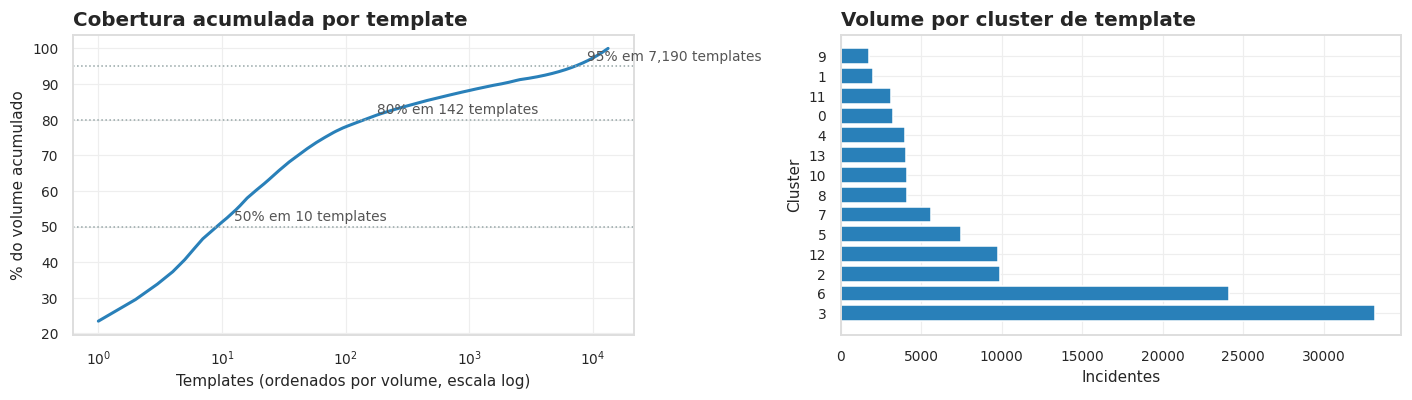

,templates,incidentes
cluster,,
3,42,33155
6,5950,24078
2,66,9892
12,894,9793
5,4,7457
7,20,5593
8,33,4143
10,4,4138
13,6,4029


In [171]:
fig, axes = novo_grafico("Estrutura da coluna Descrição Resumida", figsize=(13, 3.8), ncols=2)

cob = dim_template["pct_volume"].cumsum()
axes[0].plot(np.arange(1, len(cob) + 1), cob, color=PALETA["destaque"], lw=2)
for alvo in (50, 80, 95):
    n = int((cob < alvo).sum() + 1)
    axes[0].axhline(alvo, color=PALETA["neutro"], ls=":", lw=1)
    axes[0].annotate(f"{alvo}% em {n:,} templates", (n, alvo), textcoords="offset points",
                     xytext=(8, 4), fontsize=9, color="#555555")
axes[0].set_xscale("log")
axes[0].set_title("Cobertura acumulada por template")
axes[0].set_xlabel("Templates (ordenados por volume, escala log)")
axes[0].set_ylabel("% do volume acumulado")

perfil_cluster = (
    dim_template.query("cluster >= 0")
    .groupby("cluster", observed=True)
    .agg(templates=("template_descricao", "size"), incidentes=("incidentes", "sum"))
    .sort_values("incidentes", ascending=False)
)
axes[1].barh(perfil_cluster.index.astype(str), perfil_cluster["incidentes"], color=PALETA["destaque"])
axes[1].set_title("Volume por cluster de template")
axes[1].set_xlabel("Incidentes")
axes[1].set_ylabel("Cluster")
finalizar(fig)

perfil_cluster

In [172]:
# Exemplos por cluster — a leitura qualitativa que decide se o agrupamento tem sentido.
for c in perfil_cluster.index[:6]:
    sub = dim_template.query("cluster == @c").nlargest(3, "incidentes")
    print(f"--- cluster {c} | {perfil_cluster.loc[c, 'incidentes']:,} incidentes "
          f"| {perfil_cluster.loc[c, 'templates']} templates ---")
    for _, l in sub.iterrows():
        print(f"    [{l['incidentes']:>6,}] P{l['prioridade_dominante']} {l['template_descricao'][:88]}")
    print()

--- cluster 3 | 33,155 incidentes | 42 templates ---
    [28,728] P4 problem: check application monitoring
    [ 4,281] P4 problem: check application monitoring vip
    [    20] P3 problem: check application monitoring on saasworker

--- cluster 6 | 24,078 incidentes | 5950 templates ---
    [   684] P2 problem: perf teste asp - web test fail
    [   542] P4 problem: gurnicorn is down
    [   529] P4 problem: pool: <PATH> has backends off

--- cluster 2 | 9,892 incidentes | 66 templates ---
    [ 5,285] P4 problem: free disk space is less than <NUM>% on volume /
    [   977] P4 problem: /: free disk space is less than <NUM>
    [   735] P4 problem: free disk space is less than <NUM>% on volume <PATH>

--- cluster 12 | 9,793 incidentes | 894 templates ---
    [ 1,307] P4 problem: <NOME_NUM> - <NOME_NUM> - servidores com erro no hypervisor: <NUM>
    [   899] P2 problem: postfix with <NUM> messages on <NOME_NUM>
    [   722] P3 problem: hank instalation recipes::domains::domain::<NOME_NU

In [173]:
# Quais classes são novas em R3? Se o salto vier de tipos de alerta inéditos, é confirmação
# de mudança de instrumentação — e não de mais problemas nos mesmos lugares.
por_classe = (
    fato_diario_classe.merge(fato_diario[["data", "regime"]].drop_duplicates(), on="data",
                             how="left", suffixes=("", "_dia"))
    .groupby(["classe_descricao", "regime"], observed=True)["abertos"].sum()
    .unstack("regime", fill_value=0)
    .rename(columns=lambda r: f"R{r}")
)
for c in ("R1", "R2", "R3"):
    if c not in por_classe.columns:
        por_classe[c] = 0
por_classe["pct_r2"] = por_classe["R2"] / por_classe["R2"].sum() * 100
por_classe["pct_r3"] = por_classe["R3"] / por_classe["R3"].sum() * 100
por_classe["delta_pp"] = (por_classe["pct_r3"] - por_classe["pct_r2"]).round(2)
por_classe["nova_em_r3"] = ((por_classe["R2"] == 0) & (por_classe["R3"] > 0)).astype(int)

resultado = por_classe.sort_values("delta_pp", ascending=False)
print(f"Classes que só existem em R3: {int(resultado['nova_em_r3'].sum())} "
      f"({resultado.loc[resultado['nova_em_r3'] == 1, 'R3'].sum():,} incidentes)")
resultado.head(12).round(2)

Classes que só existem em R3: 0 (0 incidentes)


regime,R1,R2,R3,pct_r2,pct_r3,delta_pp,nova_em_r3
classe_descricao,,,,,,,
erro_aplicacao,190,4961,31819,16.48,34.82,18.35,0
performance_degradada,10,1374,18837,4.56,20.61,16.05,0
infraestrutura_rede,103,3602,13629,11.96,14.92,2.95,0
banco_de_dados,7,782,2552,2.60,2.79,0.20,0
disponibilidade_servico,58,4958,12821,16.47,14.03,-2.44,0
certificado_seguranca,43,1235,674,4.10,0.74,-3.36,0
job_processamento,12,1799,2068,5.97,2.26,-3.71,0
backup_replicacao,8,1763,1661,5.86,1.82,-4.04,0
outros,46,1383,460,4.59,0.50,-4.09,0


### Como fechar esta lacuna

O que está pronto: template, cluster e a tabela diária por classe. O que falta é a etapa de
nomeação, e há duas rotas:

1. **Rotular por LLM** (`USAR_LLM = True` em §2.9). Rotula os templates que cobrem 95 % do volume
   — algumas centenas de chamadas. É o caminho recomendado.
2. **Rotular à mão os 20–30 templates de maior volume** e deixar o resto em "outros". Considerando
   a concentração da curva de cobertura, isso já resolve boa parte do volume e custa uma hora.

Em qualquer das duas, o teste de utilidade é o mesmo: *a série diária de alguma classe antecipa
o volume de P2/P3?* Se sim, a classe vira feature. Se não, ela serve para explicar o passado —
o que tem valor para a área, mas não entra no modelo.

## 3.8 Diagnóstico das séries alvo

Última parada antes da modelagem: entender a estrutura temporal do que se quer prever.

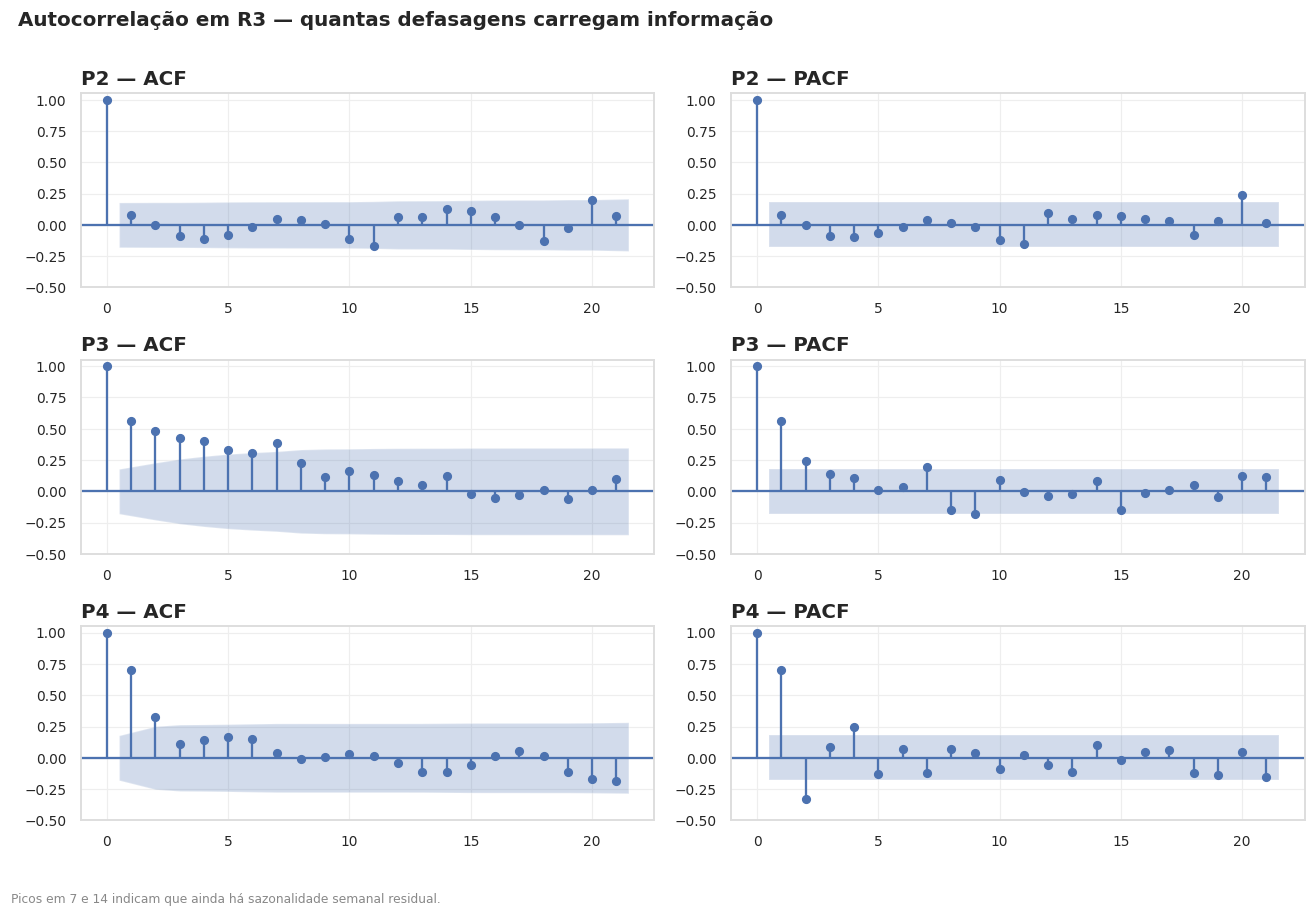

In [174]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

alvo_r3 = fato_diario_prioridade.query("regime == 3")

fig, axes = plt.subplots(len(PRIORIDADES_ALVO), 2, figsize=(12, 2.6 * len(PRIORIDADES_ALVO)))
for i, p in enumerate(PRIORIDADES_ALVO):
    s = alvo_r3.query("prioridade == @p").set_index("data")["abertos"]
    plot_acf(s, lags=21, ax=axes[i, 0], title=f"P{p} — ACF")
    plot_pacf(s, lags=21, ax=axes[i, 1], method="ywm", title=f"P{p} — PACF")
    for ax in axes[i]:
        ax.set_ylim(-0.5, 1.05)
fig.suptitle("Autocorrelação em R3 — quantas defasagens carregam informação",
             y=1.0, fontsize=13, weight="bold", x=0.01, ha="left")
finalizar(fig, "Picos em 7 e 14 indicam que ainda há sazonalidade semanal residual.")

In [175]:
def ranquear_candidatas(tabela, coluna_alvo, excluir_prefixos=("y_",), minimo=0.05):
    """
    Correlação de Spearman entre cada candidata numérica e o alvo, dentro de R3.

    Spearman e não Pearson: as contagens têm cauda pesada e a relação de interesse é monotônica,
    não linear. Isto é um filtro de triagem, não seleção de features — colunas correlacionadas
    entre si aparecem todas no topo.
    """
    base = tabela.dropna(subset=[coluna_alvo])
    numericas = base.select_dtypes(include=[np.number]).columns
    candidatas = [
        c for c in numericas
        if not c.startswith(excluir_prefixos) and c not in (coluna_alvo, "prioridade", "regime")
    ]
    linhas = []
    for c in candidatas:
        s = base[c]
        if s.nunique(dropna=True) < 3:
            continue
        r = s.corr(base[coluna_alvo], method="spearman")
        if pd.notna(r) and abs(r) >= minimo:
            linhas.append({"feature": c, "spearman": round(r, 3), "abs": abs(r)})
    return pd.DataFrame(linhas).sort_values("abs", ascending=False).drop(columns="abs")


for p in PRIORIDADES_ALVO:
    sub = tabela_modelo_longa.query("regime == 3 and prioridade == @p")
    ranking = ranquear_candidatas(sub, "y_abertos_d1")
    print(f"\n=== P{p} — top 15 candidatas para y_abertos_d1 (R3) ===")
    print(ranking.head(15).to_string(index=False))


=== P2 — top 15 candidatas para y_abertos_d1 (R3) ===
                   feature  spearman
                cos_semana      0.31
                sen_semana      0.28
     abertos_monitoramento      0.24
     abertos_hor_comercial      0.24
taxa_sem_intervencao_total     -0.23
                   abertos      0.23
                  fechados      0.23
             ics_distintos      0.22
           fechados_manual      0.22
          times_ativos_dia      0.21
       times_com_incidente      0.21
             abertos_lag_2     -0.21
             abertos_lag_3     -0.21
     kpi_violado_media_30d      0.20
      kpi_violado_soma_30d      0.20

=== P3 — top 15 candidatas para y_abertos_d1 (R3) ===
                   feature  spearman
                   abertos      0.52
     abertos_monitoramento      0.49
                  fechados      0.49
            fechados_lag_1      0.49
             ics_distintos      0.49
  fechados_sem_intervencao      0.48
 abertos_sem_classificacao      0.48
  

In [176]:
# Baselines. Nenhum modelo deve ser aceito sem bater estes números.
def avaliar_baselines(tabela, prioridade, horizonte=1):
    sub = (
        tabela.query("regime == 3 and prioridade == @prioridade")
        .sort_values("data").dropna(subset=[f"y_abertos_d{horizonte}"])
    )
    y = sub[f"y_abertos_d{horizonte}"].to_numpy()
    candidatos = {
        "ingênuo (valor de hoje)": sub["abertos"].to_numpy(),
        "sazonal (mesmo dia da semana anterior)": sub["abertos_lag_7"].to_numpy(),
        "média móvel 7d": sub["abertos_media_7d"].to_numpy(),
        "média móvel 30d": sub["abertos_media_30d"].to_numpy(),
    }
    linhas = []
    for nome, yhat in candidatos.items():
        m = ~np.isnan(yhat)
        erro = y[m] - yhat[m]
        linhas.append({
            "baseline": nome,
            "MAE": np.abs(erro).mean(),
            "RMSE": np.sqrt((erro**2).mean()),
            "MAPE %": np.mean(np.abs(erro) / np.maximum(y[m], 1)) * 100,
        })
    return pd.DataFrame(linhas).assign(prioridade=prioridade, horizonte=horizonte)


baselines = pd.concat(
    [avaliar_baselines(tabela_modelo_longa, p, h) for p in PRIORIDADES_ALVO for h in HORIZONTES],
    ignore_index=True,
)
baselines.pivot_table(index=["prioridade", "baseline"], columns="horizonte",
                      values=["MAE", "MAPE %"]).round(2)

MAE        MAPE %      
horizonte                                              1      7      1     7
prioridade baseline                                                         
2          ingênuo (valor de hoje)                 57.76  61.40  88.61 81.10
           média móvel 30d                         48.09  48.75  81.13 82.57
           média móvel 7d                          53.66  53.02  91.52 94.09
           sazonal (mesmo dia da semana anterior)  66.00  59.77  99.56 91.94
3          ingênuo (valor de hoje)                 71.50  80.47  39.40 40.14
           média móvel 30d                         78.63  87.71  40.48 41.89
           média móvel 7d                          64.60  82.52  38.00 42.39
           sazonal (mesmo dia da semana anterior)  91.91  93.60  47.67 42.49
4          ingênuo (valor de hoje)                 58.71 103.48  12.72 23.86
           média móvel 30d                        104.80 112.64  21.73 24.59
           média móvel 7d                          83.67  98.48  18.55 21.82
           sazonal (mesmo dia da semana anterior) 131.82 134.64  29.44 29.82

## 3.9 Restrição de validação

Este é o limite que nenhuma feature resolve, e ele precisa estar explícito.

O regime R3 tem **122 dias**. Uma validação temporal honesta (treino no passado, teste no futuro)
precisa que o teste seja inteiramente posterior ao treino e que ambos estejam no mesmo regime —
treinar em R2 e testar em R3 é treinar em outra distribuição.

Com 122 dias, sobra pouco: um teste de 30 dias deixa 92 de treino, o que é raso para um modelo com
dezenas de features. Três caminhos, em ordem de preferência:

1. **Validação por janela deslizante com origem móvel** (`TimeSeriesSplit` com poucos folds e
   `gap` igual ao horizonte). Usa melhor os dados que uma divisão única.
2. **Modelo enxuto.** Com 92 dias de treino, um modelo de contagem regularizado (Poisson/Negativo
   Binomial) com 5–10 features tende a superar um gradient boosting com 80 colunas. O ranking de
   §3.8 serve de ponto de partida, mas convém remover redundância — as janelas móveis são
   fortemente correlacionadas entre si.
3. **Pooling entre prioridades.** Dada a alta correlação de §3.4, um modelo do total com rateio
   por prioridade triplica o volume efetivo de treino. Vale medir contra três modelos separados.

**O que não fazer:** validação cruzada aleatória. Ela embaralha o tempo, e com autocorrelação forte
o resultado vira otimismo puro.

**Quando reavaliar:** se a §3.1 apontar uma quebra R4 nos dados novos, o histórico volta a zero.
Vale reexecutar aquela seção a cada carga.

---
# 4. Salvamento das tabelas finais

Um único bloco de escrita, com contrato explícito.

In [179]:
CATALOGO = {
    "s_fato_diario_prioridade": {
        "descricao": "Grão dia × prioridade. Tabela principal: alvo, aberturas, fechamentos, janelas.",
        "chave": ["data", "prioridade"],
    },
    "s_fato_diario_prioridade_turno": {
        "descricao": "Grão dia × prioridade × turno. Sazonalidade intradiária.",
        "chave": ["data", "prioridade", "turno"],
    },
    "s_fato_diario": {
        "descricao": "Grão dia. Contexto agregado + calendário.",
        "chave": ["data"],
    },
    "s_fato_diario_time": {
        "descricao": "Grão dia × time. Carga por grupo designado.",
        "chave": ["data", "time"],
    },
    "s_fato_diario_classe": {
        "descricao": "Grão dia × classe de descrição. Volume por tipo de alerta.",
        "chave": ["data", "classe_descricao"],
    },
    "s_ft_ic": {
        "descricao": "Grão dia. Features de item de configuração (ativos, outliers, inativos).",
        "chave": ["data"],
    },
    "s_ft_concentracao": {
        "descricao": "Grão dia. Concentração da carga entre times (HHI).",
        "chave": ["data"],
    },
    "s_dim_calendario": {"descricao": "Grão dia. Calendário e sazonalidade.", "chave": ["data"]},
    "s_dim_ic": {"descricao": "Grão IC. Perfil consolidado.", "chave": ["ic"]},
    "s_dim_ic_regime": {"descricao": "Grão IC × regime.", "chave": ["ic", "regime"]},
    "s_dim_time_regime": {"descricao": "Grão time × regime.", "chave": ["time", "regime"]},
    "s_dim_template": {"descricao": "Grão template de descrição.", "chave": ["template_descricao"]},
    "s_tabela_modelo": {
        "descricao": "Grão dia, formato largo. Matriz pronta para modelagem (R2+R3).",
        "chave": ["data"],
    },
}


def salvar(tabela, nome, pasta=SAVE_PATH, catalogo=CATALOGO, sep=";", encoding="utf-8-sig"):
    """
    Grava validando o contrato: a chave existe, é única e não tem nulo.

    """
    meta = catalogo.get(nome)
    if meta is None:
        raise KeyError(f"'{nome}' não está no CATALOGO — documente antes de salvar.")

    chave = meta["chave"]
    faltando = set(chave) - set(tabela.columns)
    if faltando:
        raise ValueError(f"{nome}: chave ausente {sorted(faltando)}")
    if tabela[chave].isna().any().any():
        raise ValueError(f"{nome}: chave {chave} contém nulo")
    dups = int(tabela.duplicated(subset=chave).sum())
    if dups:
        raise ValueError(f"{nome}: {dups} linhas duplicadas na chave {chave}")

    Path(pasta).mkdir(parents=True, exist_ok=True)
    caminho = f"{pasta}{nome}.csv"
    tabela.to_csv(caminho, index=False, sep=sep, encoding=encoding)
    print(f"  {nome:<34} {tabela.shape[0]:>7,} x {tabela.shape[1]:>3}  ->  {caminho}")
    return caminho

In [180]:
print("Gravando tabelas silver\n")

salvar(fato_diario_prioridade, "s_fato_diario_prioridade")
salvar(fato_diario_prioridade_turno, "s_fato_diario_prioridade_turno")
salvar(fato_diario, "s_fato_diario")
salvar(fato_diario_time, "s_fato_diario_time")
salvar(fato_diario_classe, "s_fato_diario_classe")
salvar(ft_ic, "s_ft_ic")
salvar(ft_concentracao, "s_ft_concentracao")
salvar(dim_calendario, "s_dim_calendario")
salvar(dim_ic, "s_dim_ic")
salvar(dim_ic_regime, "s_dim_ic_regime")
salvar(dim_time_regime, "s_dim_time_regime")
salvar(dim_template, "s_dim_template")
salvar(tabela_modelo, "s_tabela_modelo")

print("\nCatálogo:\n")
print(
    pd.DataFrame(CATALOGO).T
    .assign(chave=lambda d: d["chave"].map(lambda k: " + ".join(k)))
    .to_string()
)

Gravando tabelas silver

  s_fato_diario_prioridade             3,285 x  54  ->  /content/drive/MyDrive/fiap/segundo ano/challenge_locaweb/2_silver_data/s_fato_diario_prioridade.csv
  s_fato_diario_prioridade_turno      13,140 x   6  ->  /content/drive/MyDrive/fiap/segundo ano/challenge_locaweb/2_silver_data/s_fato_diario_prioridade_turno.csv
  s_fato_diario                        1,095 x  43  ->  /content/drive/MyDrive/fiap/segundo ano/challenge_locaweb/2_silver_data/s_fato_diario.csv
  s_fato_diario_time                  18,615 x   7  ->  /content/drive/MyDrive/fiap/segundo ano/challenge_locaweb/2_silver_data/s_fato_diario_time.csv
  s_fato_diario_classe                12,045 x   7  ->  /content/drive/MyDrive/fiap/segundo ano/challenge_locaweb/2_silver_data/s_fato_diario_classe.csv
  s_ft_ic                              1,095 x  14  ->  /content/drive/MyDrive/fiap/segundo ano/challenge_locaweb/2_silver_data/s_ft_ic.csv
  s_ft_concentracao                    1,095 x   4  ->  /content/

## Próximos passos

**Antes de modelar** — decisões, não código:

1. Fechar com a área se o alvo inclui `Sem Intervenção` (§3.2). É a decisão de maior impacto.
2. Fechar se D+7 é a contagem no dia ou o acumulado da semana (§2.10).
3. Confirmar se P4 tem meta de OLA (§2.7).
4. Confirmar os 17 grupos designados contra a lista de 14 times (§3.5).

**Para completar as lacunas:**

5. Rodar a rotulagem por LLM dos templates (§2.9, `USAR_LLM = True`) e refazer §3.7 com nomes de
   negócio no lugar dos clusters.
6. Testar se alguma classe de descrição antecipa P2/P3, com a mesma função de correlação defasada
   usada nos times.

**Na modelagem:**

7. Começar pelos baselines de §3.8. Um modelo que não bate a média móvel de 7 dias não deve seguir.
8. Preferir modelo de contagem (Poisson / Binomial Negativa) a regressão gaussiana — o alvo é
   contagem, tem cauda longa e não pode ser negativo.
9. Validar por origem móvel com `gap` igual ao horizonte, nunca por embaralhamento (§3.9).
10. Reexecutar §3.1 a cada carga nova. Uma quebra R4 invalida o treino.